<a href="https://colab.research.google.com/github/tejasmanojav/P-B-and-Friends/blob/main/PB_index_backtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## SimFin API Key Setup


1. Click on the "Secrets" tab in the left-hand panel.
2. Click "+ New secret" and set the **Name** to `SIMFIN_API_KEY`.
3. Paste your SimFin API key into the **Value** field.
4. Make sure to enable "Notebook access" for this secret.

Once done, the notebook will be able to securely access your API key.

### **Setup & Package Installation**

This cell installs necessary Python packages (`yfinance`, `simfin`, `quantstats`) and imports them for use in the notebook. It also configures `matplotlib` for plotting and sets up the `simfin` data directory for caching downloaded data.

In [ ]:
# ==============================================================================
# 1. Setup & Package Installation
# ==============================================================================
!pip install -q yfinance simfin quantstats

import yfinance as yf
import simfin as sf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


plt.style.use('seaborn-v0_8-whitegrid')

# SimFin Configuration
# Downloads bulk CSVs once and caches them to disk for lightning-fast reloading
sf.set_data_dir('~/Downloads/simfin_data/')

import warnings
warnings.filterwarnings('ignore')
print("✅ Environment configured. SimFin caching directory set up!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 2.6 MB/s eta 0:00:00
✅ Environment configured. SimFin caching directory set up!


### **SimFin API Key Loading**

This cell securely loads your SimFin API key from Colab secrets, ensuring it's not exposed directly in the notebook. It then configures the `simfin` library with this key.

In [ ]:
# Used to securely store your API key
from google.colab import userdata

# Retrieve the API key from Colab secrets, remove all carriage returns and newlines, then strip any remaining whitespace
SIMFIN_API_KEY_RAW = userdata.get('SIMFIN_API_KEY')
SIMFIN_API_KEY = SIMFIN_API_KEY_RAW.replace('\r', '').replace('\n', '').strip()
sf.set_api_key(SIMFIN_API_KEY)

print("✅ SimFin API key loaded from Colab secrets.")

✅ SimFin API key loaded from Colab secrets.


### **Load Raw Data from SimFin**

This cell loads various financial datasets (companies, industries, balance sheets, income statements, and share prices) from SimFin into pandas DataFrames. It also prints the date ranges of the loaded price and fundamental data.

In [ ]:
print("📥 Loading bulk data from SimFin (Local cache will be used if already downloaded)...")

# Load raw dataframes
df_companies_raw = sf.load_companies(market='us')
df_industries_raw = sf.load_industries()
df_balance = sf.load_balance(variant='quarterly', market='us')
df_income = sf.load_income(variant='quarterly', market='us')
df_prices = sf.load_shareprices(variant='daily', market='us')

start_dt = df_prices.index.get_level_values('Date').min().strftime('%Y-%m-%d')
end_dt = df_prices.index.get_level_values('Date').max().strftime('%Y-%m-%d')

print(f"Price data loaded from {start_dt} to {end_dt}")
print(f"Income data loaded from {df_income.index.get_level_values('Report Date').min().strftime('%Y-%m-%d')} to {df_income.index.get_level_values('Report Date').max().strftime('%Y-%m-%d')}")
print(f"Balance data loaded from {df_balance.index.get_level_values('Report Date').min().strftime('%Y-%m-%d')} to {df_balance.index.get_level_values('Report Date').max().strftime('%Y-%m-%d')}")

📥 Loading bulk data from SimFin (Local cache will be used if already downloaded)...
Dataset "us-companies" not on disk.
- Downloading ... 100.0%
- Extracting zip-file ... Done!
- Loading from disk ... Done!
Dataset "industries" not on disk.
- Downloading ... 100.0%
- Extracting zip-file ... Done!
- Loading from disk ... Done!
Dataset "us-balance-quarterly" not on disk.
- Downloading ... 100.0%
- Extracting zip-file ... Done!
- Loading from disk ... Done!
Dataset "us-income-quarterly" not on disk.
- Downloading ... 100.0%
- Extracting zip-file ... Done!
- Loading from disk ... Done!
Dataset "us-shareprices-daily" not on disk.
- Downloading ... 100.0%
- Extracting zip-file ... Done!
- Loading from disk ... Done!
Price data loaded from 2020-08-10 to 2025-07-11
Income data loaded from 2020-08-31 to 2025-06-30
Balance data loaded from 2020-08-30 to 2025-06-30


### **Process `df_companies` with Sector Information**

This cell prepares the `df_companies` DataFrame by merging it with `df_industries` to include `Sector` information for each company. It sets 'Ticker' as the index and displays the head of the processed DataFrame and unique sectors.

In [ ]:
# Reset df_industries_raw index to make 'IndustryId' a column for merging
df_industries = df_industries_raw.reset_index()
# Ensure 'IndustryId' in df_industries is of nullable integer type
df_industries['IndustryId'] = df_industries['IndustryId'].astype('Int64')

# Start with df_companies_raw which has 'Ticker' as its index.
# Reset its index to make 'Ticker' a column, then create df_companies.
df_companies = df_companies_raw.reset_index().copy()
df_companies['IndustryId'] = df_companies['IndustryId'].astype('Int64')

# Merge df_companies (now with 'Ticker' as a column) with df_industries
# The merge is performed on the 'IndustryId' columns.
df_companies = pd.merge(
    df_companies,
    df_industries[['IndustryId', 'Sector']],
    on='IndustryId',
    how='left'
)

# Set 'Ticker' back as the index for df_companies after the merge
df_companies = df_companies.set_index('Ticker')

print("✅ df_companies prepared with 'Sector' column and 'Ticker' as index.")
# Display the first few rows and info to confirm structure
display(df_companies.head())
print(df_companies.info())

# Print distinct sectors available in the dataset
print("\n🌍 Distinct Sectors available for backtesting:")
print(df_companies['Sector'].dropna().unique().tolist())

✅ df_companies prepared with 'Sector' column and 'Ticker' as index.


,SimFinId,Company Name,IndustryId,ISIN,End of financial year (month),Number Employees,Business Summary,Market,CIK,Main Currency,Sector
Ticker,,,,,,,,,,,
A,45846,AGILENT TECHNOLOGIES INC,106001,US00846U1016,10.0,16400.0,Agilent Technologies Inc is engaged in life sc...,us,1090872.0,USD,Healthcare
A21,1333027,Li Auto Inc.,<NA>,NaN,12.0,NaN,NaN,us,1791706.0,USD,NaN
AA,367153,Alcoa Corp,110004,US0138721065,12.0,12900.0,Alcoa Corp is an integrated aluminum company. ...,us,1675149.0,USD,Basic Materials
AAC,7962652,Ares Acquisition Corporation,104002,US0003071083,12.0,NaN,Ares Acquisition Corporation does not have sig...,us,1829432.0,USD,Financial Services
AACB,18959140,Artius II Acquisition Inc. Class A Ordinary Sh...,104002,KYG0509J1076,12.0,NaN,Artius II Acquisition Inc. is a blank check co...,us,2034334.0,USD,Financial Services


<class 'pandas.core.frame.DataFrame'>
Index: 6588 entries, A to nan
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   SimFinId                       6588 non-null   int64  
 1   Company Name                   6552 non-null   object 
 2   IndustryId                     6276 non-null   Int64  
 3   ISIN                           5387 non-null   object 
 4   End of financial year (month)  6553 non-null   float64
 5   Number Employees               5752 non-null   float64
 6   Business Summary               6289 non-null   object 
 7   Market                         6588 non-null   object 
 8   CIK                            6576 non-null   float64
 9   Main Currency                  6588 non-null   object 
 10  Sector                         6276 non-null   object 
dtypes: Int64(1), float64(3), int64(1), object(6)
memory usage: 624.1+ KB
None

🌍 Distinct Sectors available for backte

### **Initial Data Completeness Statistics**

This cell calculates and prints the number and percentage of companies missing key information such as sector mapping, income data, and balance sheet data. This provides an initial overview of data availability.

In [ ]:
print("--- Data Statistics on Missing Information ---")

# 1. Companies missing sector mapping
missing_sector_companies = df_companies['Sector'].isnull().sum()
total_companies = len(df_companies)
print(f"\n1. Companies missing Sector mapping: {missing_sector_companies} out of {total_companies} ({missing_sector_companies/total_companies:.2%})")

# 2. Companies missing income data
# Get all unique tickers from df_companies
all_companies_tickers = set(df_companies.index.unique())

# Get unique tickers present in df_income (from its MultiIndex)
companies_with_income_data = set(df_income.index.get_level_values('Ticker').unique())

# Find companies that are in df_companies but not in df_income
companies_missing_income = all_companies_tickers - companies_with_income_data
num_companies_missing_income = len(companies_missing_income)

print(f"2. Companies entirely missing Income data (from df_companies): {num_companies_missing_income} out of {total_companies} ({num_companies_missing_income/total_companies:.2%})")

# 3. Companies missing balance data
# Get unique tickers present in df_balance (from its MultiIndex)
companies_with_balance_data = set(df_balance.index.get_level_values('Ticker').unique())

# Find companies that are in df_companies but not in df_balance
companies_missing_balance = all_companies_tickers - companies_with_balance_data
num_companies_missing_balance = len(companies_missing_balance)

print(f"3. Companies entirely missing Balance data (from df_companies): {num_companies_missing_balance} out of {total_companies} ({num_companies_missing_balance/total_companies:.2%})")

print("\nNote: 'Entirely missing' means no records for the company in the respective SimFin DataFrame within the loaded date range.")

--- Data Statistics on Missing Information ---

1. Companies missing Sector mapping: 312 out of 6588 (4.74%)
2. Companies entirely missing Income data (from df_companies): 2762 out of 6588 (41.92%)
3. Companies entirely missing Balance data (from df_companies): 2761 out of 6588 (41.91%)

Note: 'Entirely missing' means no records for the company in the respective SimFin DataFrame within the loaded date range.


In [ ]:
# Combine tickers missing either income or balance data
companies_missing_financial_data = companies_missing_income.union(companies_missing_balance)

print(f"Total unique companies missing income or balance data: {len(companies_missing_financial_data)}")

# Define what a 'penny stock' is for this analysis
penny_stock_threshold = 1.0

missing_data_penny_stocks = []
missing_data_with_price = []
missing_data_no_price = []

for ticker in companies_missing_financial_data:
    try:
        # Select all dates for the ticker, then get 'Adj. Close', drop NaNs, and take the last value
        ticker_prices = df_prices.loc[(ticker, slice(None)), 'Adj. Close'].dropna()
        if not ticker_prices.empty:
            latest_price = ticker_prices.iloc[-1]
            missing_data_with_price.append((ticker, latest_price))
            if latest_price < penny_stock_threshold:
                missing_data_penny_stocks.append(ticker)
        else:
            missing_data_no_price.append(ticker)
    except KeyError: # Ticker not found in df_prices or 'Adj. Close' column missing for all dates
        missing_data_no_price.append(ticker)
    except Exception as e:
        print(f"DEBUG: Unhandled error for ticker {ticker}: {e}")
        missing_data_no_price.append(ticker)

num_missing_data_penny_stocks = len(missing_data_penny_stocks)
num_missing_data_with_price = len(missing_data_with_price)
num_missing_data_no_price = len(missing_data_no_price)

print(f"\nCompanies missing financial data with available price: {num_missing_data_with_price}")
print(f"Companies missing financial data and no price data: {num_missing_data_no_price}")

if num_missing_data_with_price > 0:
    percentage_penny_stocks = (num_missing_data_penny_stocks / num_missing_data_with_price) * 100
    print(f"\nOut of those with price data, {num_missing_data_penny_stocks} are penny stocks (< ${penny_stock_threshold:.2f}).")
    print(f"This represents {percentage_penny_stocks:.2f}% of companies missing financial data that have price data.")
else:
    print("\nNo companies missing financial data have price data to analyze for penny stock status.")

print("\n--- Note on Filtering ---\nThe backtesting functions (`selector_pb`, `selector_pb_roa`, `selector_pb_roe`, `selector_pb_roa_roe`) already include a `min_price` parameter (defaulting to 0.0, but typically set to 1.0 in `selector_kwargs`) which filters out stocks below a specified price at *each rebalance date*. This effectively addresses the concern of penny stocks impacting the portfolio at the point of selection.")

Total unique companies missing income or balance data: 2762

Companies missing financial data with available price: 2271
Companies missing financial data and no price data: 491

Out of those with price data, 213 are penny stocks (< $1.00).
This represents 9.38% of companies missing financial data that have price data.

--- Note on Filtering ---
The backtesting functions (`selector_pb`, `selector_pb_roa`, `selector_pb_roe`, `selector_pb_roa_roe`) already include a `min_price` parameter (defaulting to 0.0, but typically set to 1.0 in `selector_kwargs`) which filters out stocks below a specified price at *each rebalance date*. This effectively addresses the concern of penny stocks impacting the portfolio at the point of selection.


In [ ]:
# --- Part 1: Initial Data Statistics (from original cell 7HB5QzdefAis) ---
print("--- Data Statistics on Missing Information ---")

# 1. Companies missing sector mapping
missing_sector_companies = df_companies['Sector'].isnull().sum()
total_companies = len(df_companies)
print(f"\n1. Companies missing Sector mapping: {missing_sector_companies} out of {total_companies} ({missing_sector_companies/total_companies:.2%})")

# Get all unique tickers from df_companies
all_companies_tickers = set(df_companies.index.unique())

# 2. Companies missing income data
# Get unique tickers present in df_income (from its MultiIndex)
companies_with_income_data = set(df_income.index.get_level_values('Ticker').unique())

# Find companies that are in df_companies but not in df_income
companies_missing_income = all_companies_tickers - companies_with_income_data
num_companies_missing_income = len(companies_missing_income)

print(f"2. Companies entirely missing Income data (from df_companies): {num_companies_missing_income} out of {total_companies} ({num_companies_missing_income/total_companies:.2%})")

# 3. Companies missing balance data
# Get unique tickers present in df_balance (from its MultiIndex)
companies_with_balance_data = set(df_balance.index.get_level_values('Ticker').unique())

# Find companies that are in df_companies but not in df_balance
companies_missing_balance = all_companies_tickers - companies_with_balance_data
num_companies_missing_balance = len(companies_missing_balance)

print(f"3. Companies entirely missing Balance data (from df_companies): {num_companies_missing_balance} out of {total_companies} ({num_companies_missing_balance/total_companies:.2%})")

print("\nNote: 'Entirely missing' means no records for the company in the respective SimFin DataFrame within the loaded date range.")


# --- Part 2: Penny Stock Analysis (from original cell e9edbef5) ---
print("\n--- Penny Stock Analysis for Companies Missing Financial Data ---")
# Combine tickers missing either income or balance data
companies_missing_financial_data = companies_missing_income.union(companies_missing_balance)

print(f"Total unique companies missing income or balance data: {len(companies_missing_financial_data)}")

# Define what a 'penny stock' is for this analysis
penny_stock_threshold = 1.0

missing_data_penny_stocks = []
missing_data_with_price = []
missing_data_no_price = []

for ticker in companies_missing_financial_data:
    try:
        # Select all dates for the ticker, then get 'Adj. Close', drop NaNs, and take the last value
        ticker_prices = df_prices.loc[(ticker, slice(None)), 'Adj. Close'].dropna()
        if not ticker_prices.empty:
            latest_price = ticker_prices.iloc[-1]
            missing_data_with_price.append((ticker, latest_price))
            if latest_price < penny_stock_threshold:
                missing_data_penny_stocks.append(ticker)
        else:
            missing_data_no_price.append(ticker)
    except KeyError: # Ticker not found in df_prices or 'Adj. Close' column missing for all dates
        missing_data_no_price.append(ticker)
    except Exception as e:
        # print(f"DEBUG: Unhandled error for ticker {ticker}: {e}") # Commented out debug print
        missing_data_no_price.append(ticker)

num_missing_data_penny_stocks = len(missing_data_penny_stocks)
num_missing_data_with_price = len(missing_data_with_price)
num_missing_data_no_price = len(missing_data_no_price)

print(f"\nCompanies missing financial data with available price: {num_missing_data_with_price}")
print(f"Companies missing financial data and no price data: {num_missing_data_no_price}")

if num_missing_data_with_price > 0:
    percentage_penny_stocks = (num_missing_data_penny_stocks / num_missing_data_with_price) * 100
    print(f"\nOut of those with price data, {num_missing_data_penny_stocks} are penny stocks (< ${penny_stock_threshold:.2f}).")
    print(f"This represents {percentage_penny_stocks:.2f}% of companies missing financial data that have price data.")
else:
    print("\nNo companies missing financial data have price data to analyze for penny stock status.")

print("\n--- Note on Filtering ---\nThe backtesting functions (`selector_pb`, `selector_pb_roa`, `selector_pb_roe`, `selector_pb_roa_roe`) already include a `min_price` parameter (defaulting to 0.0, but typically set to 1.0 in `selector_kwargs`) which filters out stocks below a specified price at *each rebalance date*. This effectively addresses the concern of penny stocks impacting the portfolio at the point of selection.")


# --- Part 3: Detailed Data Completeness Breakdown (from original cell c99122c3) ---
print("\n--- Detailed Data Completeness Breakdown: Sector, Income, and Price Data ---")

# Recalculate or retrieve base sets (ensure all are updated)
all_companies_tickers = set(df_companies.index.unique())
total_companies = len(all_companies_tickers)

# Companies with sector mapping
companies_with_sector = set(df_companies['Sector'].dropna().index.unique())

# Companies with price data
companies_with_price_data = set(df_prices.index.get_level_values('Ticker').unique())


# Derive missing sets
companies_missing_sector = all_companies_tickers - companies_with_sector
companies_missing_price = all_companies_tickers - companies_with_price_data
# companies_missing_income and companies_missing_balance are already defined from Part 1

print(f"Total unique companies in df_companies: {total_companies}\n")

# 1. Companies with sector mapping AND income data, BUT no price data
scenario_1 = (companies_with_sector.intersection(companies_with_income_data)) - companies_with_price_data
fraction_1 = len(scenario_1) / total_companies
print(f"1. Companies with sector AND income data, but NO price data: {len(scenario_1)} ({fraction_1:.2%})")

# 2. Companies with price data AND income data, BUT no sector mapping
scenario_2 = (companies_with_price_data.intersection(companies_with_income_data)) - companies_with_sector
fraction_2 = len(scenario_2) / total_companies
print(f"2. Companies with price AND income data, but NO sector mapping: {len(scenario_2)} ({fraction_2:.2%})")

# 3. Companies with sector mapping AND price data, BUT no income data
scenario_3 = (companies_with_sector.intersection(companies_with_price_data)) - companies_with_income_data
fraction_3 = len(scenario_3) / total_companies
print(f"3. Companies with sector AND price data, but NO income data: {len(scenario_3)} ({fraction_3:.2%})")

# 4. Companies with sector mapping AND price data AND income data (fully complete)
scenario_4 = companies_with_sector.intersection(companies_with_price_data).intersection(companies_with_income_data)
fraction_4 = len(scenario_4) / total_companies
print(f"4. Companies with sector AND price AND income data (fully complete): {len(scenario_4)} ({fraction_4:.2%})")

# 5. Companies with NO sector mapping AND NO income data AND NO price data (completely incomplete)
scenario_5 = companies_missing_sector.intersection(companies_missing_income).intersection(companies_missing_price)
fraction_5 = len(scenario_5) / total_companies
print(f"5. Companies with NO sector AND NO income AND NO price data: {len(scenario_5)} ({fraction_5:.2%})")

# Additional common cases based on the original phrasing

# "sector mapping or income data but no price data"
scenario_A = (companies_with_sector.union(companies_with_income_data)) - companies_with_price_data
fraction_A = len(scenario_A) / total_companies
print(f"\nAdditional - Companies with (sector OR income) data, but NO price data: {len(scenario_A)} ({fraction_A:.2%})")

# "price data but no sector mapping or no income data"
# This interpretation: price data present, AND (sector missing OR income missing)
scenario_B = companies_with_price_data.intersection(companies_missing_sector.union(companies_missing_income))
fraction_B = len(scenario_B) / total_companies
print(f"Additional - Companies with price data, but (NO sector OR NO income data): {len(scenario_B)} ({fraction_B:.2%})")


# --- Part 4: Summary Table Generation (from original cell c2db5d4b and previous turn's generation logic) ---
print("\n--- Summary of Data Completeness: Missing vs. Available ---")

# Create a dictionary to hold the data for the DataFrame
summary_data = {
    'Income Data': {
        'Available': len(companies_with_income_data),
        'Missing': len(companies_missing_income)
    },
    'Balance Data': {
        'Available': len(companies_with_balance_data),
        'Missing': len(companies_missing_balance)
    },
    'Price Data': {
        'Available': len(companies_with_price_data),
        'Missing': len(companies_missing_price)
    },
    'Sector Mapping': {
        'Available': len(companies_with_sector),
        'Missing': len(companies_missing_sector)
    }
}

# Create the DataFrame
df_completeness_summary = pd.DataFrame(summary_data)


# --- New Part: Negative Equity & Net Income Analysis ---
print("\n--- Analysis: Companies with Negative Equity AND Negative Net Income ---")

# 1. Identify companies with negative equity (at any point in df_balance)
# Ensure we only consider companies present in df_companies
all_companies_tickers_in_companies_df = set(df_companies.index.unique())
neg_equity_tickers_raw = set(df_balance[df_balance['Total Equity'] < 0].index.get_level_values('Ticker').unique())
neg_equity_tickers = neg_equity_tickers_raw.intersection(all_companies_tickers_in_companies_df)
print(f"Number of companies with negative equity (at any point): {len(neg_equity_tickers)}")

# 2. Identify companies with negative net income (at any point in df_income)
neg_income_tickers_raw = set(df_income[df_income['Net Income'] < 0].index.get_level_values('Ticker').unique())
neg_income_tickers = neg_income_tickers_raw.intersection(all_companies_tickers_in_companies_df)
print(f"Number of companies with negative net income (at any point): {len(neg_income_tickers)}")

# 3. Find companies with both negative equity AND negative net income
companies_with_neg_equity_and_income = neg_equity_tickers.intersection(neg_income_tickers)
num_companies_neg_eq_inc = len(companies_with_neg_equity_and_income)
print(f"Number of companies with BOTH negative equity AND negative net income: {num_companies_neg_eq_inc}")

# 4. Categorize these companies into penny vs. non-penny stocks
penny_stock_threshold = 1.0 # Re-using the same threshold
neg_financial_penny_stocks = []
neg_financial_non_penny_stocks = []
neg_financial_no_price = []

for ticker in companies_with_neg_equity_and_income:
    try:
        ticker_prices = df_prices.loc[(ticker, slice(None)), 'Adj. Close'].dropna()
        if not ticker_prices.empty:
            latest_price = ticker_prices.iloc[-1]
            if latest_price < penny_stock_threshold:
                neg_financial_penny_stocks.append(ticker)
            else:
                neg_financial_non_penny_stocks.append(ticker)
        else:
            neg_financial_no_price.append(ticker)
    except KeyError:
        neg_financial_no_price.append(ticker)
    except Exception as e:
        neg_financial_no_price.append(ticker)

num_neg_financial_penny_stocks = len(neg_financial_penny_stocks)
num_neg_financial_non_penny_stocks = len(neg_financial_non_penny_stocks)
num_neg_financial_no_price = len(neg_financial_no_price)

print(f"\nBreakdown of companies with negative equity AND negative net income:")
print(f"  - Penny Stocks (< ${penny_stock_threshold:.2f}): {num_neg_financial_penny_stocks}")
print(f"  - Non-Penny Stocks (>= ${penny_stock_threshold:.2f}): {num_neg_financial_non_penny_stocks}")
print(f"  - No Price Data Available: {num_neg_financial_no_price}")


# --- Update Summary Table to include the new metric as a column ---

# Create a new column in df_completeness_summary
df_completeness_summary['Negative Equity & Net Income'] = pd.Series(dtype=object)

# Populate the new column for 'Available' and 'Missing' rows (as N/A or empty for this new category)
df_completeness_summary.loc['Available', 'Negative Equity & Net Income'] = '' # Not applicable
df_completeness_summary.loc['Missing', 'Negative Equity & Net Income'] = '' # Not applicable

# Now, create additional rows for the breakdown. These rows will only have values in the new column.
new_breakdown_rows = pd.DataFrame({
    'Negative Equity & Net Income': [
        f"Total: {num_companies_neg_eq_inc}",
        f"Penny Stocks: {num_neg_financial_penny_stocks}",
        f"Non-Penny Stocks: {num_neg_financial_non_penny_stocks}"
    ]
}, index=[
    'Negative Eq & Inc (Total)',
    'Negative Eq & Inc (Penny)',
    'Negative Eq & Inc (Non-Penny)'
])

# Concatenate the main summary with the breakdown rows.
# Filling other columns of new_breakdown_rows with empty strings to avoid NaN display issues
for col in df_completeness_summary.columns:
    if col != 'Negative Equity & Net Income':
        new_breakdown_rows[col] = ''

df_completeness_summary_final = pd.concat([df_completeness_summary, new_breakdown_rows])


# Re-create df_completeness_summary_formatted from df_completeness_summary_final
df_completeness_summary_formatted = pd.DataFrame(index=df_completeness_summary_final.index)

for col in df_completeness_summary_final.columns:
    for idx in df_completeness_summary_final.index:
        count_or_value = df_completeness_summary_final.loc[idx, col]

        if count_or_value == '': # Handle empty cells
            df_completeness_summary_formatted.loc[idx, col] = ''
        elif idx in ['Available', 'Missing'] and col != 'Negative Equity & Net Income':
            # Format Available/Missing percentages for original columns
            total_companies_for_pct = len(all_companies_tickers)
            pct = (count_or_value / total_companies_for_pct) * 100
            df_completeness_summary_formatted.loc[idx, col] = f"{int(count_or_value)} ({pct:.2f}%)"
        else: # For the new column, or breakdown rows, just display as is (already formatted as string)
            df_completeness_summary_formatted.loc[idx, col] = str(count_or_value)


display(df_completeness_summary_formatted.style.set_caption("Data Completeness Overview (with percentages and Negative Financials)"))

--- Data Statistics on Missing Information ---

1. Companies missing Sector mapping: 312 out of 6588 (4.74%)
2. Companies entirely missing Income data (from df_companies): 2762 out of 6588 (41.92%)
3. Companies entirely missing Balance data (from df_companies): 2761 out of 6588 (41.91%)

Note: 'Entirely missing' means no records for the company in the respective SimFin DataFrame within the loaded date range.

--- Penny Stock Analysis for Companies Missing Financial Data ---
Total unique companies missing income or balance data: 2762

Companies missing financial data with available price: 2271
Companies missing financial data and no price data: 491

Out of those with price data, 213 are penny stocks (< $1.00).
This represents 9.38% of companies missing financial data that have price data.

--- Note on Filtering ---
The backtesting functions (`selector_pb`, `selector_pb_roa`, `selector_pb_roe`, `selector_pb_roa_roe`) already include a `min_price` parameter (defaulting to 0.0, but typical

,Income Data,Balance Data,Price Data,Sector Mapping,Negative Equity & Net Income
Available,3787 (57.83%),3788 (57.84%),5890 (89.94%),6276 (95.83%),
Missing,2762 (42.17%),2761 (42.16%),659 (10.06%),273 (4.17%),
Negative Eq & Inc (Total),,,,,Total: 682
Negative Eq & Inc (Penny),,,,,Penny Stocks: 167
Negative Eq & Inc (Non-Penny),,,,,Non-Penny Stocks: 451


### **Load and Prepare SimFin Data into Sparse Quarterly Matrices**

This function (`load_and_prep_simfin_data`) processes the raw SimFin data into sparse quarterly matrices for prices, market capitalization, equity, P/B, ROA, ROE, and shares. This step is crucial for efficient backtesting as it creates time-aligned, quarterly snapshots of the data.

In [ ]:
def load_and_prep_simfin_data(start_date, end_date, freq='Q'):
    print("🔄 Processing Data into Sparse Quarterly Matrices...")
    rebalance_dates = pd.date_range(start=start_date, end=end_date, freq=freq)

    # Process Prices - Reset index first to access 'Date' and 'Ticker' as columns
    prices_pivot = df_prices.reset_index().pivot(index='Date', columns='Ticker', values='Adj. Close')
    prices_q = prices_pivot.reindex(rebalance_dates, method='ffill')

    # Process Fundamentals (Pivot strictly by 'Report Date')
    d_balance = df_balance.reset_index().dropna(subset=['Report Date'])
    d_income = df_income.reset_index().dropna(subset=['Report Date'])

    equity_q = d_balance.pivot_table(index='Report Date', columns='Ticker', values='Total Equity', aggfunc='last').reindex(rebalance_dates, method='ffill')
    assets_q = d_balance.pivot_table(index='Report Date', columns='Ticker', values='Total Assets', aggfunc='last').reindex(rebalance_dates, method='ffill')
    shares_q = d_balance.pivot_table(index='Report Date', columns='Ticker', values='Shares (Basic)', aggfunc='last').reindex(rebalance_dates, method='ffill')

    net_income_q = d_income.pivot_table(index='Report Date', columns='Ticker', values='Net Income', aggfunc='last').reindex(rebalance_dates, method='ffill')

    # Pre-compute Core Metrics Matrices
    mcap_q = prices_q * shares_q
    pb_q = prices_q / (equity_q / shares_q)
    roa_q = net_income_q / assets_q
    roe_q = net_income_q / equity_q

    matrices = {
        'prices': prices_q,
        'mcap': mcap_q,
        'equity': equity_q,
        'pb': pb_q,
        'roa': roa_q,
        'roe': roe_q,
        'shares': shares_q
    }

    print(f"✅ Data Preparation Complete! Rebalance Dates: {len(rebalance_dates)}")
    return matrices, rebalance_dates

# Global execution
data_matrices, rebalance_dates = load_and_prep_simfin_data(start_dt, end_dt, 'Q')

🔄 Processing Data into Sparse Quarterly Matrices...
✅ Data Preparation Complete! Rebalance Dates: 20


### **Define Sector-Benchmark Mapping**

This cell defines a dictionary `sector_benchmark_map` that maps each sector to a list of relevant ETF benchmark tickers. The primary ETF in each list is used for backtesting comparisons.

In [ ]:
sector_benchmark_map = {
    'Technology': ['XLK', 'VGT', 'VITAX'],
    'Healthcare': ['XLV', 'VHT', 'VGHCX'],
    'Financial Services': ['XLF', 'VFH', 'VFAIX'],
    'Consumer Defensive': ['XLP', 'VDC', 'VCSAX'],
    'Consumer Cyclical': ['XLY', 'VCR', 'VCDAX'],
    'Industrials': ['XLI', 'VIS', 'VSPIX'],
    'Energy': ['XLE', 'VDE', 'VENAX'],
    'Basic Materials': ['XLB', 'VAW', 'VMIAX'],
    'Real Estate': ['XLRE', 'VNQ', 'VGSLX'],
    'Utilities': ['XLU', 'VPU', 'VUIAX'],
    'Business Services': ['IYZ', 'VOX', 'VTCAX']
}


### **`selector_kwargs` Template**

This markdown cell serves as a template or documentation for the possible attributes that can be passed to `selector_kwargs`. These parameters control the filtering and ranking logic within the stock selection functions.

In [ ]:

# This section serves as a documentation or template for the possible attributes of `selector_kwargs`.
#
# selector_kwargs = {
#     'mcap_min_percentile_level': 25,  # Minimum percentile for Market Cap (e.g., 25 means mcap >= 25th percentile)
#     'bv_min_percentile_level': 10,    # Minimum percentile for Book Value (equity) (e.g., 10 means equity >= 10th percentile)
#     'pb_max_percentile_level': 10,    # Maximum percentile for Price/Book (e.g., 10 means pb <= 10th percentile)
#     'ranking_metric': 'pb',           # Metric used for final ranking (e.g., 'pb', 'equity', 'mcap')
#     'rank_order': 'Asc',              # Order for ranking ('Asc' for ascending, 'Desc' for descending)
#     'min_price': 1.0,                 # Minimum share price to filter out micro-caps or anomaly stocks
#     'basket_size': 10                 # Number of stocks to select for the portfolio basket
# }

### **Modular Helper Functions for Stock Selection**

This cell defines two core helper functions for the backtesting process:

*   `get_constituents_at_date`: Retrieves a list of tickers actively trading within a specified `sector` on a given `date`, based on available price data.
*   `ranking_function`: Ranks a list of `filtered_candidates` based on a specified `ranking_metric` and `rank_order` (ascending or descending), using the pre-calculated data matrices.

In [ ]:
# ==============================================================================
# 3a. Modular Helpers & Selector 1 (P/B Percentile Based)
# ==============================================================================

def get_constituents_at_date(sector, date, df_companies, prices_matrix):
    sector_tickers_from_companies = df_companies[df_companies['Sector'] == sector].index.tolist()
    if date in prices_matrix.index:
        available_tickers_in_prices_matrix = prices_matrix.columns.intersection(sector_tickers_from_companies).tolist()
        if not available_tickers_in_prices_matrix: return []
        valid_prices = prices_matrix.loc[date, available_tickers_in_prices_matrix].dropna()
        return valid_prices.index.tolist()
    return []

def ranking_function(filtered_candidates, date, matrices, **kwargs):
    metric = kwargs.get('ranking_metric', 'pb')
    ascending = kwargs.get('rank_order', 'Asc')
    #print(f"DEBUG: Active Metric = {metric}, Active Order = {ascending}")
    ascending = True if ascending == 'Asc' else False
    metrics_data = matrices[metric].loc[date, filtered_candidates]
    ranked = metrics_data.sort_values(ascending=ascending)
    return ranked.index.tolist()

### **Calculate Sector-Quarter Percentile Distributions for Factors**

This cell calculates and stores percentile distributions for various financial metrics (Market Cap, P/B, ROA, ROE, Equity) across different sectors and rebalance dates. These percentiles are essential for dynamic, percentile-based filtering in the stock selection process.

In [ ]:
import json

print("📊 Calculating Sector-Quarter Percentile Distributions for Factors...")

percentile_data = []
metrics_to_analyze = ['mcap', 'pb', 'roa', 'roe', 'equity']
percentiles_to_calculate = [0, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.80, 0.90, 0.95, 0.99, 1.0]

# Iterate through each sector defined in the benchmark map
for sector in sector_benchmark_map.keys():
    # Iterate through each rebalance date
    for r_date in rebalance_dates:
        row_data = {'Sector': sector, 'Date': r_date}

        # Get active tickers for the current sector and date
        active_tickers = get_constituents_at_date(sector, r_date, df_companies, data_matrices['prices'])

        if not active_tickers: # If no active tickers, skip this sector-date combination
            for metric in metrics_to_analyze:
                for p in percentiles_to_calculate:
                    row_data[f'{metric}_{int(p*100)}'] = np.nan
            percentile_data.append(row_data)
            continue

        for metric in metrics_to_analyze:
            # Filter active_tickers to only include those present in the current metric's columns
            available_tickers_for_metric = data_matrices[metric].columns.intersection(active_tickers)

            # Extract metric values for active tickers at the current date
            metric_series = data_matrices[metric].loc[r_date, available_tickers_for_metric].dropna()

            if not metric_series.empty:
                for p in percentiles_to_calculate:
                    percentile_value = metric_series.quantile(p)
                    row_data[f'{metric}_{int(p*100)}'] = percentile_value
            else:
                # If no data, set percentiles to NaN
                for p in percentiles_to_calculate:
                    row_data[f'{metric}_{int(p*100)}'] = np.nan

        percentile_data.append(row_data)

# Create a DataFrame from the collected data
df_factor_percentiles = pd.DataFrame(percentile_data)

# Set a meaningful index for easier access and analysis
df_factor_percentiles = df_factor_percentiles.set_index(['Sector', 'Date'])

print("✅ Sector-Quarter Factor Percentiles Calculated!")

# Add the df_factor_percentiles to data_matrices
data_matrices['percentiles_by_sector'] = df_factor_percentiles
print("✅ Percentile distributions added to data_matrices!")
display(data_matrices['percentiles_by_sector'].head())

# Initialize an empty dictionary for the multi-dimensional structure
multi_dimensional_percentiles = {}

# Iterate through each row of the df_factor_percentiles DataFrame
for (sector, date), row_data in df_factor_percentiles.iterrows():
    # Ensure the sector key exists
    if sector not in multi_dimensional_percentiles:
        multi_dimensional_percentiles[sector] = {}

    # Ensure the date key exists within the sector
    if date not in multi_dimensional_percentiles[sector]:
        multi_dimensional_percentiles[sector][date] = {}

    # Iterate through each metric_percentile column and its value
    for col, value in row_data.items():
        # Split the column name to extract the metric and the percentile key
        # Example: 'mcap_1th_percentile' -> metric='mcap', percentile_key='1th_percentile'
        parts = col.split('_', 1) # Split only on the first underscore
        metric = parts[0]
        percentile_key = parts[1]

        # Ensure the metric key exists within the sector and date
        if metric not in multi_dimensional_percentiles[sector][date]:
            multi_dimensional_percentiles[sector][date][metric] = {}

        # Assign the percentile value
        multi_dimensional_percentiles[sector][date][metric][percentile_key] = value

# Add the new multi-dimensional structure to data_matrices
data_matrices['multi_dimensional_percentiles'] = multi_dimensional_percentiles

print("✅ Multi-dimensional percentile data structured and added to data_matrices!")

# Display a sample of the new structure for verification
# We'll pick a specific sector, date, and metric to show the nested structure
sample_sector = list(multi_dimensional_percentiles.keys())[0]
sample_date = list(multi_dimensional_percentiles[sample_sector].keys())[0]
sample_metric = list(multi_dimensional_percentiles[sample_sector][sample_date].keys())[0]

print(f"\nSample data for Sector: '{sample_sector}', Date: '{sample_date.strftime('%Y-%m-%d')}', Metric: '{sample_metric}':")
print(json.dumps(multi_dimensional_percentiles[sample_sector][sample_date][sample_metric], indent=2))

📊 Calculating Sector-Quarter Percentile Distributions for Factors...
✅ Sector-Quarter Factor Percentiles Calculated!
✅ Percentile distributions added to data_matrices!


mcap_0        mcap_1        mcap_5       mcap_10  \
Sector     Date                                                               
Technology 2020-09-30  2146591.92  1.003651e+07  3.939877e+07  8.315366e+07   
           2020-12-31  2246916.27  1.508541e+07  4.253502e+07  1.189171e+08   
           2021-03-31   292168.58  1.668034e+07  7.275433e+07  1.676353e+08   
           2021-06-30   184555.68  2.068634e+07  9.521468e+07  1.763812e+08   
           2021-09-30   124958.87  1.697832e+07  8.628162e+07  1.633960e+08   

                            mcap_25       mcap_50       mcap_75       mcap_80  \
Sector     Date                                                                 
Technology 2020-09-30  3.562681e+08  1.887589e+09  8.552574e+09  1.045327e+10   
           2020-12-31  4.636188e+08  2.319822e+09  9.875431e+09  1.345582e+10   
           2021-03-31  5.620571e+08  2.701663e+09  9.499051e+09  1.325554e+10   
           2021-06-30  6.513689e+08  3.102468e+09  9.299423e+09  1.448764e+10   
           2021-09-30  6.497773e+08  2.905708e+09  8.274875e+09  1.332693e+10   

                            mcap_90       mcap_95  ...     equity_5  \
Sector     Date                                    ...                
Technology 2020-09-30  2.140170e+10  3.445951e+10  ...  -1293636.65   
           2020-12-31  2.421735e+10  4.155786e+10  ... -14864900.80   
           2021-03-31  2.540212e+10  4.727774e+10  ...   -645722.55   
           2021-06-30  3.025964e+10  4.872367e+10  ...  -1688730.05   
           2021-09-30  2.798105e+10  4.513064e+10  ...    736385.70   

                        equity_10    equity_25    equity_50     equity_75  \
Sector     Date                                                             
Technology 2020-09-30  13806000.0   82133000.0  381659000.0  1.288293e+09   
           2020-12-31   8840400.0   83033000.0  384427000.0  1.264746e+09   
           2021-03-31  16874000.0  102841500.0  395571000.0  1.225770e+09   
           2021-06-30  17347100.0  111814250.0  402138500.0  1.201924e+09   
           2021-09-30  26492657.5  113940250.0  434348500.0  1.287516e+09   

                          equity_80     equity_90     equity_95     equity_99  \
Sector     Date                                                                 
Technology 2020-09-30  1.708997e+09  3.662449e+09  5.809478e+09  7.298745e+10   
           2020-12-31  1.719033e+09  3.966241e+09  7.361874e+09  7.748264e+10   
           2021-03-31  1.697090e+09  3.911458e+09  7.406728e+09  7.651201e+10   
           2021-06-30  1.656586e+09  3.807820e+09  7.299908e+09  7.495277e+10   
           2021-09-30  1.647815e+09  3.860938e+09  6.996600e+09  7.469871e+10   

                         equity_100  
Sector     Date                      
Technology 2020-09-30  2.129200e+11  
           2020-12-31  2.225440e+11  
           2021-03-31  2.300130e+11  
           2021-06-30  2.375650e+11  
           2021-09-30  2.445670e+11  

[5 rows x 60 columns]

✅ Multi-dimensional percentile data structured and added to data_matrices!

Sample data for Sector: 'Technology', Date: '2020-09-30', Metric: 'mcap':
{
  "0": 2146591.92,
  "1": 10036509.2522,
  "5": 39398772.586,
  "10": 83153657.76,
  "25": 356268131.91999996,
  "50": 1887588574.6799998,
  "75": 8552573782.5,
  "80": 10453269276.000002,
  "90": 21401695808.000008,
  "95": 34459508224.99998,
  "99": 654387909199.992,
  "100": 1916253030800.0
}


### **Visualize Factor Percentile Distributions**

This cell generates line plots to visualize the average percentile distributions of ROA, ROE, and P/B across different sectors. This helps in understanding how these factor values vary relative to their sector peers.

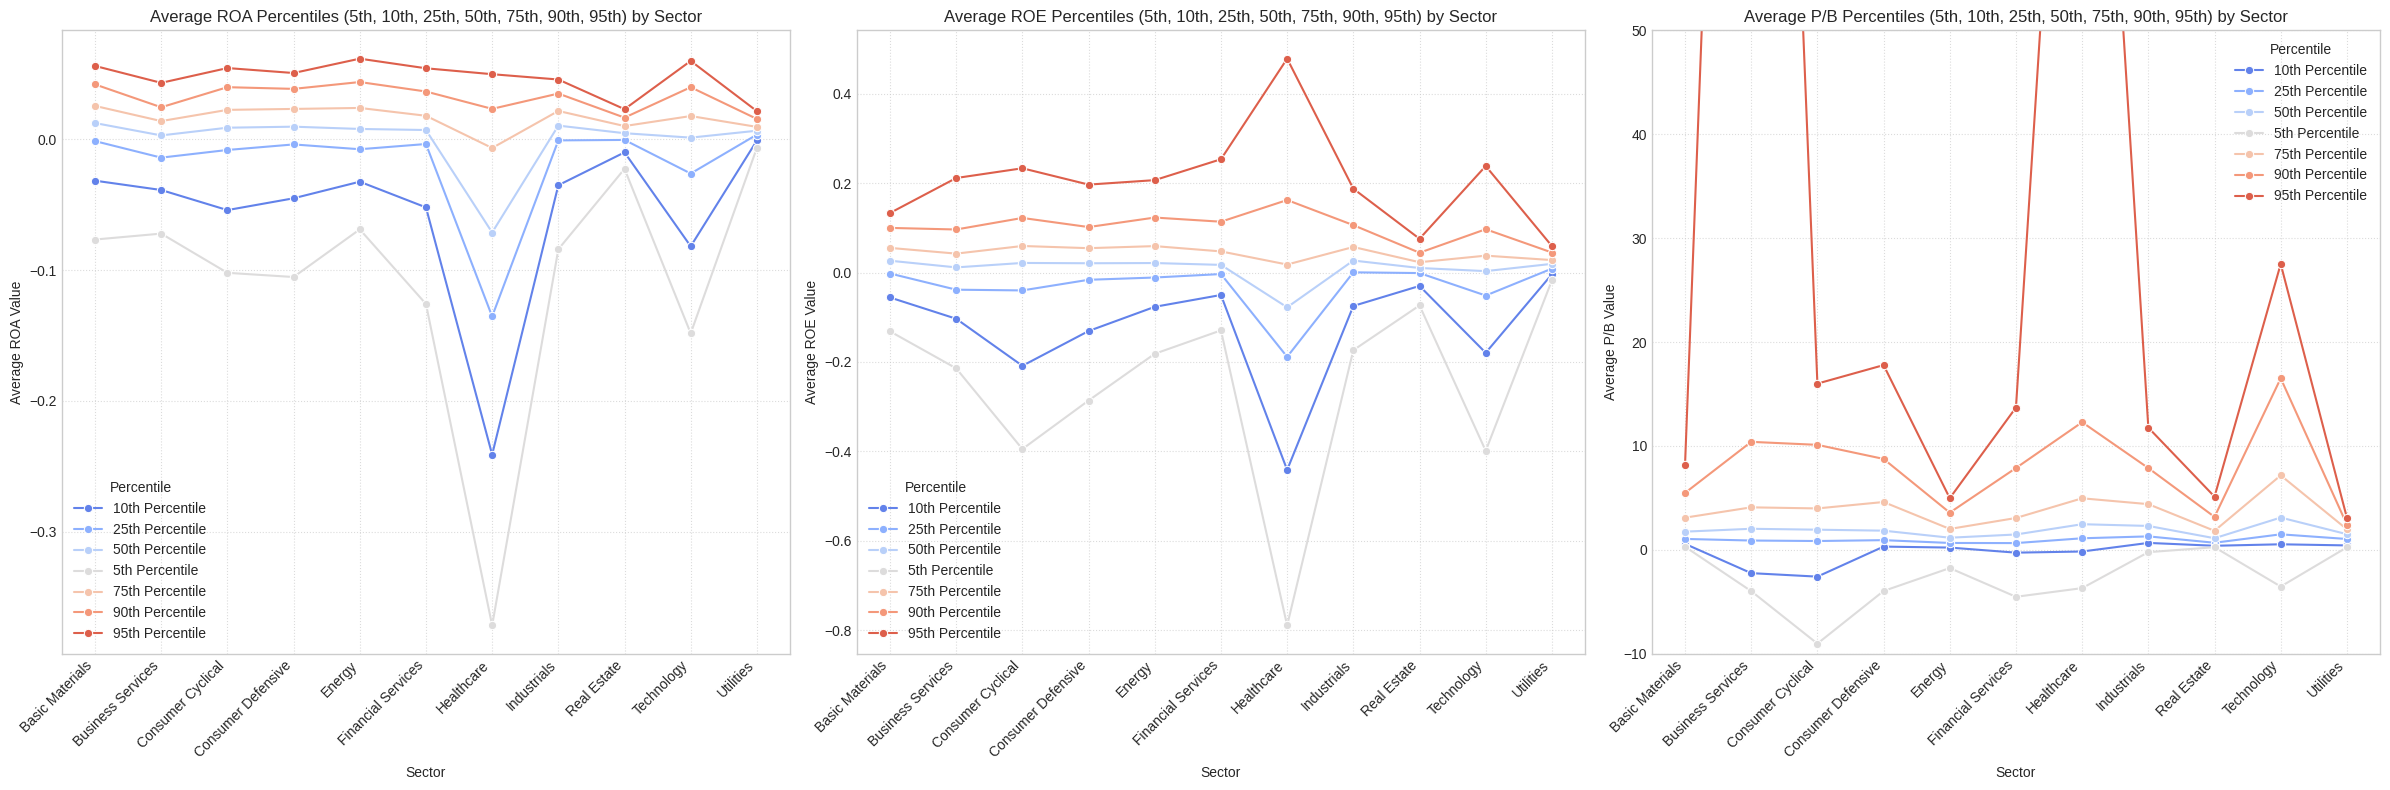

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics to plot - added 'pb'
metrics_to_plot = ['roa', 'roe', 'pb']

# Prepare data for plotting
plot_data = []

# Iterate through each sector in df_factor_percentiles
for sector in df_factor_percentiles.index.get_level_values('Sector').unique():
    sector_df = df_factor_percentiles.loc[sector]
    for metric_prefix in metrics_to_plot:
        # Select all columns related to the current metric (e.g., 'roa_0', 'roa_1', ..., 'roa_100')
        metric_columns = [col for col in sector_df.columns if col.startswith(metric_prefix)]

        # Melt these columns to create a long format
        melted_metric_df = sector_df[metric_columns].melt(var_name='Percentile_Key', value_name='Value', ignore_index=False)
        melted_metric_df['Sector'] = sector
        melted_metric_df['Metric'] = metric_prefix.upper() # ROA, ROE, or PB

        # The 'Percentile_Key' contains the percentile (e.g., 'roa_25' -> 25)
        # Extract the numeric percentile value
        melted_metric_df['Percentile'] = melted_metric_df['Percentile_Key'].apply(lambda x: int(x.split('_')[1]))

        plot_data.append(melted_metric_df)

df_plot = pd.concat(plot_data)

# Filter out NaN values, which can occur if no data was available for a sector/date/metric
df_plot.dropna(subset=['Value'], inplace=True)

# To get a clearer view of specific percentiles' average values across sectors

# Extract relevant percentile levels as requested by the user
percentile_levels_to_plot = [5, 10, 25, 50, 75, 90, 95]
filtered_df_plot = df_plot[df_plot['Percentile'].isin(percentile_levels_to_plot)].copy()

# Rename percentile values for better legend
filtered_df_plot['Percentile_Label'] = filtered_df_plot['Percentile'].astype(str) + 'th Percentile'

# Aggregate the filtered data to show average percentile levels per sector
summary_percentiles = filtered_df_plot.groupby(['Sector', 'Metric', 'Percentile_Label'])['Value'].mean().reset_index()

plt.figure(figsize=(24, 8)) # Increased figure size for 3 plots

# Plot for ROA percentiles
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
sns.lineplot(
    data=summary_percentiles[summary_percentiles['Metric'] == 'ROA'],
    x='Sector', y='Value', hue='Percentile_Label', marker='o', palette='coolwarm'
)
plt.title('Average ROA Percentiles (5th, 10th, 25th, 50th, 75th, 90th, 95th) by Sector')
plt.xlabel('Sector')
plt.ylabel('Average ROA Value')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title='Percentile')

# Plot for ROE percentiles
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
sns.lineplot(
    data=summary_percentiles[summary_percentiles['Metric'] == 'ROE'],
    x='Sector', y='Value', hue='Percentile_Label', marker='o', palette='coolwarm'
)
plt.title('Average ROE Percentiles (5th, 10th, 25th, 50th, 75th, 90th, 95th) by Sector')
plt.xlabel('Sector')
plt.ylabel('Average ROE Value')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title='Percentile')

# Plot for PB percentiles (NEW)
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
sns.lineplot(
    data=summary_percentiles[summary_percentiles['Metric'] == 'PB'],
    x='Sector', y='Value', hue='Percentile_Label', marker='o', palette='coolwarm'
)
plt.title('Average P/B Percentiles (5th, 10th, 25th, 50th, 75th, 90th, 95th) by Sector')
plt.xlabel('Sector')
plt.ylabel('Average P/B Value')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title='Percentile')
plt.ylim(-10, 50) # Set y-axis limit for P/B plot

plt.tight_layout()
plt.show()

### **Stock Selector Function: Price-to-Book (P/B) Based**

This function (`selector_pb`) serves as the base filtering mechanism for stock selection. It applies several criteria including:

*   Basic data presence and positivity checks for P/B, Market Cap, and Equity.
*   A minimum price filter to exclude micro-cap or penny stocks.
*   Dynamic, percentile-based filtering for Market Cap, Book Value (Equity), and Price-to-Book, allowing for flexible strategy definition (e.g., selecting companies with P/B below the 10th percentile within their sector).

In [ ]:
def selector_pb(ticker, date, sector_tickers, matrices, **kwargs):
    try:
        # Get current ticker's metrics
        pb = matrices['pb'].loc[date, ticker]
        mcap = matrices['mcap'].loc[date, ticker]
        equity = matrices['equity'].loc[date, ticker]

        # Get percentile cutoff levels from kwargs
        mcap_min_percentile_level = kwargs.get('mcap_min_percentile_level', None)
        bv_min_percentile_level = kwargs.get('bv_min_percentile_level', None) # Corresponds to equity
        pb_max_percentile_level = kwargs.get('pb_max_percentile_level', None)

        # Extract min_price filter
        min_price = kwargs.get('min_price', 0.0)

        # --- Basic data presence and validity checks ---
        if pd.isna(pb) or pb <= 0: return False # P/B should be positive and present
        if pd.isna(mcap) or mcap <= 0: return False # Market Cap must be positive and present
        if pd.isna(equity) or equity <= 0: return False # Equity (Book Value) must be positive and present

        # Price filter (introduced to handle CODQL anomaly)
        current_price = matrices['prices'].loc[date, ticker]
        if pd.isna(current_price) or current_price < min_price:
            return False

        # --- Dynamic Percentile-based Filtering ---
        # Get the sector of the current ticker for percentile lookup
        # Assuming df_companies is globally accessible as it is in the notebook
        sector = df_companies.loc[ticker, 'Sector']
        if pd.isna(sector): return False

        # Access the multi_dimensional_percentiles for the current sector and date
        sector_percentiles_for_date = matrices['multi_dimensional_percentiles'].get(sector, {}).get(date, {})

        # Apply Market Cap minimum percentile filter (e.g., mcap >= 25th percentile)
        if mcap_min_percentile_level is not None:
            mcap_cutoff_key = f'mcap_{int(mcap_min_percentile_level)}'
            cutoff_val = sector_percentiles_for_date.get('mcap', {}).get(mcap_cutoff_key)
            if cutoff_val is not None and mcap < cutoff_val:
                return False # Filter out if mcap is below the specified minimum percentile

        # Apply Book Value (Equity) minimum percentile filter (e.g., equity >= 10th percentile)
        if bv_min_percentile_level is not None:
            bv_cutoff_key = f'equity_{int(bv_min_percentile_level)}'
            cutoff_val = sector_percentiles_for_date.get('equity', {}).get(bv_cutoff_key)
            if cutoff_val is not None and equity < cutoff_val:
                return False # Filter out if equity is below the specified minimum percentile

        # Apply Price-to-Book maximum percentile filter (for "cheapest" stocks, e.g., pb <= 10th percentile)
        if pb_max_percentile_level is not None:
            pb_cutoff_key = f'pb_{int(pb_max_percentile_level)}'
            cutoff_val = sector_percentiles_for_date.get('pb', {}).get(pb_cutoff_key)
            if cutoff_val is not None and pb > cutoff_val:
                return False # Filter out if P/B is above the specified maximum percentile (i.e., too expensive)

        return True
    except KeyError:
        # If any data point (ticker, date) is missing in matrices or df_companies
        return False
    except Exception as e:
        # Catch any other unexpected errors during processing
        # print(f"DEBUG: Error in selector_pb for {ticker} on {date}: {e}")
        return False

### **Stock Selector Function: P/B and Return on Assets (ROA) Based**

This function (`selector_pb_roa`) extends the `selector_pb` logic by adding a quality filter based on Return on Assets (ROA). It allows for filtering stocks based on either an absolute minimum ROA value or a minimum ROA percentile within their sector, ensuring that selected stocks also meet certain profitability criteria.

In [ ]:
def selector_pb_roa(ticker, date, sector_tickers, matrices, **kwargs):
    try:
        # Correctly unpack kwargs with **
        if not selector_pb(ticker, date, sector_tickers, matrices, **kwargs):
            return False

        roa = matrices['roa'].loc[date, ticker]
        min_roa = kwargs.get('min_roa', np.nan) # Default to np.nan
        min_roa_percentile_level = kwargs.get('min_roa_percentile', np.nan) # Default to np.nan

        # Check if both are unspecified, then raise an error
        if pd.isna(min_roa) and pd.isna(min_roa_percentile_level):
            raise ValueError("At least one of 'min_roa' or 'min_roa_percentile' must be specified (not NaN).")

        if pd.isna(roa):
            return False

        # Apply absolute min_roa filter only if min_roa is specified
        if not pd.isna(min_roa) and roa < min_roa:
            return False

        # Apply percentile-based min_roa filter only if min_roa_percentile_level is specified and > 0
        if not pd.isna(min_roa_percentile_level) and min_roa_percentile_level > 0:
            sector = df_companies.loc[ticker, 'Sector']
            if pd.isna(sector): return False

            sector_percentiles_for_date = matrices['multi_dimensional_percentiles'].get(sector, {}).get(date, {})
            # FIX: Correctly access the percentile key as a string (e.g., '50')
            percentile_key_str = str(int(min_roa_percentile_level))
            cutoff_val = sector_percentiles_for_date.get('roa', {}).get(percentile_key_str)

            if cutoff_val is None:
                raise ValueError(f"ROA percentile cutoff value not found for sector {sector}, date {date.strftime('%Y-%m-%d')}, percentile {min_roa_percentile_level}")

            if roa < cutoff_val:
                return False # Filter out if ROA is below the specified minimum percentile

        return True
    except KeyError:
        return False
    except Exception as e:
        # print(f"DEBUG: Error in selector_pb_roa for {ticker} on {date}: {e}")
        return False

### **Stock Selector Function: P/B and Return on Equity (ROE) Based**

This function (`selector_pb_roe`) similarly extends the `selector_pb` logic, but incorporates a quality filter based on Return on Equity (ROE). It filters stocks based on either an absolute minimum ROE value or a minimum ROE percentile within their sector, aiming to select companies with strong profitability relative to shareholder equity.

In [ ]:
def selector_pb_roe(ticker, date, sector_tickers, matrices, **kwargs):
    try:
        # Correctly unpack kwargs with **
        if not selector_pb(ticker, date, sector_tickers, matrices, **kwargs):
            return False

        roe = matrices['roe'].loc[date, ticker]
        min_roe = kwargs.get('min_roe', np.nan)
        min_roe_percentile_level = kwargs.get('min_roe_percentile_level', np.nan)

        # Check if both are unspecified, then raise an error
        if pd.isna(min_roe) and pd.isna(min_roe_percentile_level):
            # Allow both to be nan if no ROE filter is intended for this run
            # We only raise an error if an ROE filter is explicitly requested but invalid
            # For now, let's just bypass if no ROE filter is set (both are nan)
            pass

        if pd.isna(roe):
            return False

        # Apply absolute min_roe filter only if min_roe is specified
        if not pd.isna(min_roe) and roe < min_roe:
            return False

        # Apply percentile-based min_roe filter only if min_roe_percentile_level is specified and > 0
        if not pd.isna(min_roe_percentile_level) and min_roe_percentile_level > 0:
            sector = df_companies.loc[ticker, 'Sector']
            if pd.isna(sector): return False

            sector_percentiles_for_date = matrices['multi_dimensional_percentiles'].get(sector, {}).get(date, {})
            # Correctly access the percentile key as a string (e.g., '50')
            percentile_key_str = str(int(min_roe_percentile_level))
            cutoff_val = sector_percentiles_for_date.get('roe', {}).get(percentile_key_str)

            # If a percentile level is specified but the cutoff value is not found, it implies insufficient data
            # for this sector/date to apply the filter, so we filter out the stock.
            if cutoff_val is None:
                # This case might indicate missing data for this specific percentile, so we return False
                # Alternatively, one might choose to raise an error or log a warning depending on strictness
                return False

            if roe < cutoff_val:
                return False # Filter out if ROE is below the specified minimum percentile

        return True
    except KeyError:
        # If any data point (ticker, date) is missing in matrices or df_companies
        return False
    except Exception as e:
        # print(f"DEBUG: Error in selector_pb_roe for {ticker} on {date}: {e}")
        return False

### **Stock Selector Function: P/B, ROA, and ROE Based**

This comprehensive selector function (`selector_pb_roa_roe`) combines the filtering logic of `selector_pb`, `selector_pb_roa`, and `selector_pb_roe`. It ensures that selected stocks meet criteria for value (low P/B) and multiple quality factors (high ROA and high ROE) before being considered for portfolio inclusion.

In [ ]:
def selector_pb_roa_roe(ticker, date, sector_tickers, matrices, **kwargs):
    try:
        # 1. Apply selector_pb
        if not selector_pb(ticker, date, sector_tickers, matrices, **kwargs):
            return False

        # 2. Apply selector_pb_roa
        if not selector_pb_roa(ticker, date, sector_tickers, matrices, **kwargs):
            return False

        # 3. Apply selector_pb_roe
        if not selector_pb_roe(ticker, date, sector_tickers, matrices, **kwargs):
            return False

        # If all selectors pass, return True
        return True
    except KeyError:
        # Handle cases where data for a ticker/date might be missing in matrices
        return False
    except Exception as e:
        # Catch any other unexpected errors during processing
        # print(f"DEBUG: Error in selector_pb_roa_roe for {ticker} on {date}: {e}")
        return False


### **Backtesting Engine Function (`run_backtest`)**

This function simulates the performance of a factor-based investment strategy within a specified sector against an ETF benchmark. It performs quarterly rebalancing, applies a dynamic stock selection function (like `selector_pb_roa_roe`), ranks and selects a basket of stocks, and calculates portfolio returns. It also tracks additions and removals from the portfolio for analysis.

In [ ]:
import json

def run_backtest(target_sector, etf_benchmark, start_date, end_date, selector_func, **selector_kwargs):
    print(f"🚀 Starting Backtest: {target_sector} Sector vs {etf_benchmark} Benchmark...")

    # 1. Fetch Benchmark Pricing from yfinance
    print("📈 Fetching Benchmark pricing from yfinance...")
    benchmark_data = yf.download(etf_benchmark, start=start_date, end=end_date, progress=False)
    benchmark_prices = (benchmark_data['Adj Close'] if 'Adj Close' in benchmark_data.columns else benchmark_data['Close']).squeeze()

    # Resample benchmark to quarterly
    benchmark_prices_q = benchmark_prices.resample('Q').last()
    benchmark_returns_q = benchmark_prices_q.pct_change().fillna(0.0)

    # Tracking variables
    rebalance_log = []
    previous_basket = set()
    portfolio_returns = pd.Series(0.0, index=rebalance_dates)

    print("🔄 Running explicit quarterly rebalance loop...")
    for i in range(1, len(rebalance_dates)):
        prev_date = rebalance_dates[i-1]
        curr_date = rebalance_dates[i]

        # Step A: Determine portfolio holdings
        candidates = get_constituents_at_date(target_sector, prev_date, df_companies, data_matrices['prices'])

        # Step B: Apply Dynamic Selector Function with ** unpacking to fix the TypeError
        filtered = []
        for ticker in candidates:
            if selector_func(ticker, prev_date, candidates, data_matrices, **selector_kwargs):
                filtered.append(ticker)

        # Step C: Rank and Select Top K
        ranked = ranking_function(filtered, prev_date, data_matrices,  **selector_kwargs)
        # Removed default: basket_size is now mandatory in selector_kwargs
        basket_size = selector_kwargs['basket_size']
        selected_basket = ranked[:basket_size]

        # DEBUG: Print basket size at each rebalance
        print(f"  Rebalance Date: {prev_date.strftime('%Y-%m-%d')}, Selected Basket Size: {len(selected_basket)}")

        # Step D: Delta Tracking
        curr_set = set(selected_basket)
        rebalance_log.append({
            'Date': prev_date,
            'Basket_Size': len(selected_basket),
            'Added': list(curr_set - previous_basket),
            'Removed': list(previous_basket - curr_set)
        })
        previous_basket = curr_set

        # Step E: Calculate Return
        if len(selected_basket) > 0:
            p_prev = data_matrices['prices'].loc[prev_date, selected_basket]
            p_curr = data_matrices['prices'].loc[curr_date, selected_basket]
            stock_returns = (p_curr - p_prev) / p_prev
            portfolio_returns.loc[curr_date] = stock_returns.mean()

    portfolio_returns, benchmark_returns_q = portfolio_returns.align(benchmark_returns_q, join='inner')
    if isinstance(benchmark_returns_q, pd.DataFrame):
        benchmark_returns_q = benchmark_returns_q.iloc[:, 0]
    benchmark_returns_q.name = None

    log_df = pd.DataFrame(rebalance_log).set_index('Date')
    print("✅ Backtest Simulation Complete!")
    return portfolio_returns, benchmark_returns_q, log_df

### **Performance Evaluation Function (`evaluate_performance`)**

This function takes portfolio and benchmark returns, calculates cumulative equity curves, and plots them for visual comparison. It also displays a summary of periodic returns and calculates total returns for both the strategy and the benchmark, providing a high-level performance overview.

In [ ]:
def evaluate_performance(portfolio_ret, benchmark_ret, sector, benchmark_name):
    # Compute Cumulative Equity Curves
    port_cum = (1.0 + portfolio_ret).cumprod()
    bench_cum = (1.0 + benchmark_ret).cumprod()

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(port_cum.index, port_cum.values, label=f'Custom {sector} Basket', color='#2ca02c', linewidth=2)
    plt.plot(bench_cum.index, bench_cum.values, label=f'{benchmark_name} Benchmark', color='#1f77b4', linewidth=2, linestyle='--')

    plt.title(f"Performance: {sector} vs {benchmark_name}", fontsize=14, fontweight='bold')
    plt.legend(loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

    # Summary Statistics
    summary = pd.DataFrame({
        'Strategy': portfolio_ret,
        'Benchmark': benchmark_ret,
        'Excess': portfolio_ret - benchmark_ret
    })

    # Ensure date-only index for display
    summary.index = summary.index.date

    total_port_ret = port_cum.iloc[-1] - 1.0
    total_bench_ret = bench_cum.iloc[-1] - 1.0

    print(f"\n📊 Total Return: Strategy {total_port_ret:.2%}, Benchmark {total_bench_ret:.2%}")

    # Pretty print using the correct variable name 'summary'
    display(summary.style.format("{:.2%}").set_caption("📈 Strategy vs Benchmark Summary"))

### **Helper Functions for Performance Metrics (CAGR, Volatility, Sharpe, Information Ratio, Beta, Max Drawdown)**

This cell defines several functions to explicitly calculate key performance and risk metrics:

*   `calc_cagr`: Calculates Compound Annual Growth Rate.
*   `calc_annualized_volatility`: Calculates annualized volatility.
*   `calc_sharpe_ratio`: Calculates the Sharpe Ratio, a risk-adjusted return metric.
*   `calc_information_ratio`: Calculates the Information Ratio, measuring active return per unit of risk.
*   `calc_beta`: Calculates Beta, a measure of systematic risk relative to the market.
*   `calc_max_drawdown`: Calculates the maximum drawdown, representing the largest peak-to-trough decline.

In [ ]:
# ==============================================================================
# a. Explicit Math: CAGR & Volatility
# ==============================================================================
# Showing the math step-by-step for absolute return generation

def calc_cagr(returns_series):
    """CAGR = (Ending Value / Beginning Value) ^ (1 / Years) - 1"""
    # 1. Calculate cumulative growth (Base 1.0)
    cumulative = (1.0 + returns_series).cumprod()
    ending_value = cumulative.iloc[-1]

    # 2. Calculate exactly how many years this spans
    days = (returns_series.index[-1] - returns_series.index[0]).days
    years = days / 365.25

    # 3. Compound Annual Growth Rate
    cagr = (ending_value ** (1 / years)) - 1
    return cagr

def calc_annualized_volatility(returns_series, periods_per_year=4):
    """
    Volatility scales with the square root of time.
    Since our base returns are Quarterly, we multiply by sqrt(4).
    """
    return returns_series.std() * np.sqrt(periods_per_year)

# ==============================================================================
# b. Explicit Math: Risk-Adjusted Returns (Sharpe & Info Ratio)
# ==============================================================================

def calc_sharpe_ratio(returns_series, risk_free_rate=0.02, periods_per_year=4):
    """Sharpe = (Annualized Return - Risk Free Rate) / Annualized Volatility"""
    cagr = calc_cagr(returns_series)
    volatility = calc_annualized_volatility(returns_series, periods_per_year)

    return (cagr - risk_free_rate) / volatility

def calc_information_ratio(port_returns, bench_returns, periods_per_year=4):
    """
    Information Ratio = Active Return / Tracking Error
    Tells you if the active risk you took was actually rewarded.
    """
    # 1. Active Return: difference in annualized returns
    active_return = calc_cagr(port_returns) - calc_cagr(bench_returns)

    # 2. Tracking Error: standard deviation of the DIFFERENCE in returns (annualized)
    excess_returns = port_returns - bench_returns
    tracking_error = excess_returns.std() * np.sqrt(periods_per_year)

    if tracking_error == 0: return 0
    return active_return / tracking_error

# ==============================================================================
# c. Explicit Math: Relative Risk (Beta & Max Drawdown)
# ==============================================================================

def calc_beta(port_returns, bench_returns):
    """
    Beta = Covariance(Portfolio, Benchmark) / Variance(Benchmark)
    If Beta < 1,  portfolio is less volatile than the benchmark.
    """
    covariance = port_returns.cov(bench_returns)
    variance = bench_returns.var()
    return covariance / variance

def calc_max_drawdown(returns_series):
    """Calculates the largest peak-to-trough drop in portfolio value."""
    # 1. Calculate cumulative return curve
    cumulative = (1.0 + returns_series).cumprod()

    # 2. Calculate a running maximum of the cumulative curve
    running_max = cumulative.cummax()

    # 3. Calculate the percentage drop from the running maximum
    drawdown = (cumulative - running_max) / running_max

    # 4. The Maximum Drawdown is the lowest point in this drawdown series
    return drawdown.min()

def calc_alpha(port_returns, bench_returns, risk_free_rate=0.0):
    """
    Calculates the Capital Asset Pricing Model (CAPM) Alpha.
    Alpha = Portfolio Return - (Risk-Free Rate + Beta * (Benchmark Return - Risk-Free Rate))
    It uses Compound Annual Growth Rate (CAGR) for returns.
    """
    # Use existing CAGR function for portfolio and benchmark returns
    cagr_port = calc_cagr(port_returns)
    cagr_bench = calc_cagr(bench_returns)

    # Calculate Beta using the CAPM beta function
    beta = calc_beta(port_returns, bench_returns)

    if np.isnan(beta):
        return np.nan # If beta cannot be calculated, alpha cannot be either

    # CAPM Expected Return for the portfolio
    capm_expected_return = risk_free_rate + beta * (cagr_bench - risk_free_rate)

    # Alpha is the difference between actual portfolio return and CAPM expected return
    alpha = cagr_port - capm_expected_return
    return alpha, beta


### **Helper Functions for Broad Market Backtesting**

This cell defines a function `get_all_active_tickers_at_date` to retrieve all actively trading tickers on a given date, which is used in the `run_broad_market_backtest` function. The `run_broad_market_backtest` function itself is an adaptation of `run_backtest` to perform backtesting across the entire market (not confined to a single sector) against a broad market benchmark like SPY.

In [ ]:
def get_all_active_tickers_at_date(date, df_companies_unused, prices_matrix):
    """
    Returns a list of all tickers that have valid (non-NaN) prices on a given date.
    `df_companies_unused` is included for signature compatibility but not used in this function.
    """
    if date in prices_matrix.index:
        valid_prices = prices_matrix.loc[date].dropna()
        return valid_prices.index.tolist()
    return []

def run_broad_market_backtest(broad_market_name, broad_market_benchmark_ticker, start_date, end_date, selector_func, **selector_kwargs):
    print(f"🚀 Starting Broad Market Backtest: {broad_market_name} vs {broad_market_benchmark_ticker}...")

    # 1. Fetch Benchmark Pricing from yfinance
    print(f"📈 Fetching Benchmark pricing for {broad_market_benchmark_ticker} from yfinance...")
    benchmark_data = yf.download(broad_market_benchmark_ticker, start=start_date, end=end_date, progress=False)
    benchmark_prices = (benchmark_data['Adj Close'] if 'Adj Close' in benchmark_data.columns else benchmark_data['Close']).squeeze()

    # Resample benchmark to quarterly
    benchmark_prices_q = benchmark_prices.resample('Q').last()
    benchmark_returns_q = benchmark_prices_q.pct_change().fillna(0.0)

    # Tracking variables
    rebalance_log = []
    previous_basket = set()
    portfolio_returns = pd.Series(0.0, index=rebalance_dates)

    print("🔄 Running explicit quarterly rebalance loop for broad market...")
    for i in range(1, len(rebalance_dates)):
        prev_date = rebalance_dates[i-1]
        curr_date = rebalance_dates[i]

        # Step A: Determine portfolio holdings using the new function for all active tickers
        candidates = get_all_active_tickers_at_date(prev_date, df_companies, data_matrices['prices'])

        # Step B: Apply Dynamic Selector Function
        filtered = []
        for ticker in candidates:
            # The selector_func (selector_pb_roa_roe) will internally resolve the sector for percentile lookup
            if selector_func(ticker, prev_date, candidates, data_matrices, **selector_kwargs):
                filtered.append(ticker)

        # Step C: Rank and Select Top K
        # The ranking_function can operate on the filtered candidates without explicit sector info
        ranked = ranking_function(filtered, prev_date, data_matrices, **selector_kwargs)
        basket_size = selector_kwargs['basket_size']
        selected_basket = ranked[:basket_size]

        # DEBUG: Print basket size at each rebalance
        print(f"  Rebalance Date: {prev_date.strftime('%Y-%m-%d')}, Selected Basket Size: {len(selected_basket)}")

        # Step D: Delta Tracking
        curr_set = set(selected_basket)
        rebalance_log.append({
            'Date': prev_date,
            'Basket_Size': len(selected_basket),
            'Added': list(curr_set - previous_basket),
            'Removed': list(previous_basket - curr_set)
        })
        previous_basket = curr_set

        # Step E: Calculate Return
        if len(selected_basket) > 0:
            p_prev = data_matrices['prices'].loc[prev_date, selected_basket]
            p_curr = data_matrices['prices'].loc[curr_date, selected_basket]
            stock_returns = (p_curr - p_prev) / p_prev
            portfolio_returns.loc[curr_date] = stock_returns.mean()

    portfolio_returns, benchmark_returns_q = portfolio_returns.align(benchmark_returns_q, join='inner')
    if isinstance(benchmark_returns_q, pd.DataFrame):
        benchmark_returns_q = benchmark_returns_q.iloc[:, 0]
    benchmark_returns_q.name = None

    log_df = pd.DataFrame(rebalance_log).set_index('Date')
    print("✅ Broad Market Backtest Simulation Complete!")
    return portfolio_returns, benchmark_returns_q, log_df

### **Test Run: Single Sector Backtest**

This cell executes a single backtest for a specific sector (e.g., 'Energy') using the `selector_pb_roe` function with predefined parameters. It then evaluates and displays the performance using `evaluate_performance`. Finally, it generates a detailed institutional performance tear sheet using the `quantstats` library and reconciles key metrics with manual calculations.

🚀 Starting Backtest: Energy Sector vs XLE Benchmark...
📈 Fetching Benchmark pricing from yfinance...
🔄 Running explicit quarterly rebalance loop...
  Rebalance Date: 2020-09-30, Selected Basket Size: 10
  Rebalance Date: 2020-12-31, Selected Basket Size: 10
  Rebalance Date: 2021-03-31, Selected Basket Size: 10
  Rebalance Date: 2021-06-30, Selected Basket Size: 10
  Rebalance Date: 2021-09-30, Selected Basket Size: 10
  Rebalance Date: 2021-12-31, Selected Basket Size: 10
  Rebalance Date: 2022-03-31, Selected Basket Size: 10
  Rebalance Date: 2022-06-30, Selected Basket Size: 10
  Rebalance Date: 2022-09-30, Selected Basket Size: 10
  Rebalance Date: 2022-12-31, Selected Basket Size: 10
  Rebalance Date: 2023-03-31, Selected Basket Size: 10
  Rebalance Date: 2023-06-30, Selected Basket Size: 10
  Rebalance Date: 2023-09-30, Selected Basket Size: 10
  Rebalance Date: 2023-12-31, Selected Basket Size: 10
  Rebalance Date: 2024-03-31, Selected Basket Size: 10
  Rebalance Date: 2024-06-3

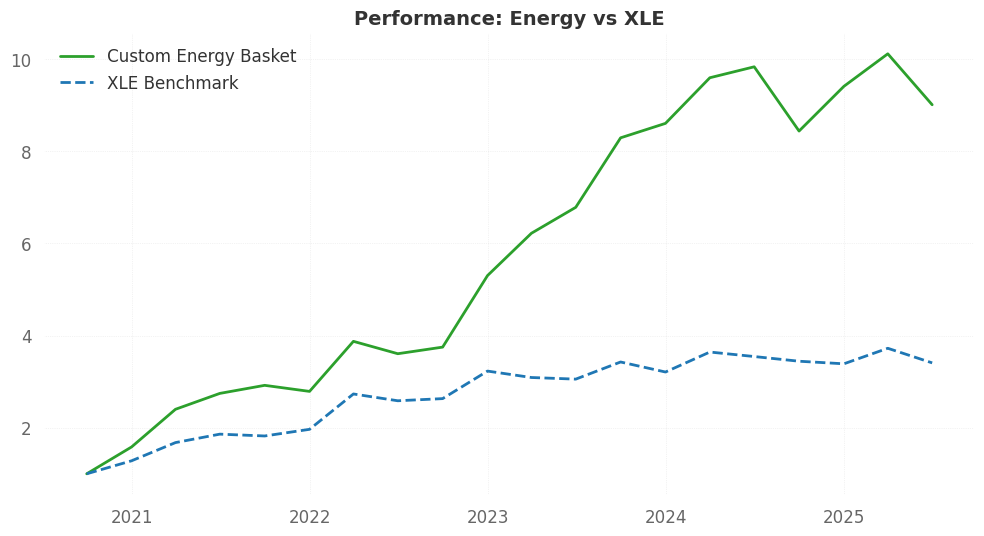


📊 Total Return: Strategy 801.14%, Benchmark 240.81%


,Strategy,Benchmark,Excess
2020-09-30,0.00%,0.00%,0.00%
2020-12-31,58.29%,28.24%,30.05%
2021-03-31,51.64%,30.82%,20.82%
2021-06-30,14.38%,10.93%,3.45%
2021-09-30,6.38%,-2.13%,8.51%
2021-12-31,-4.50%,7.93%,-12.43%
2022-03-31,38.96%,39.05%,-0.09%
2022-06-30,-6.93%,-5.40%,-1.53%
2022-09-30,3.97%,1.81%,2.16%
2022-12-31,41.40%,22.70%,18.70%


📊 Generating Institutional Tear Sheet: Custom Basket vs XLE...

Parameter       Value
--------------  ---------
Benchmark       Benchmark
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                           Benchmark       Strategy
-------------------------  --------------  ------------------
Start Period               2020-12-31      2020-12-31
End Period                 2025-06-30      2025-06-30
Risk-Free Rate             0.0%            0.0%
Time in Market             100.0%          100.0%

Cumulative Return          240.81%         801.14%
CAGR﹪                     1155581429.95%  460867577653670.6%

Sharpe                     8.48            10.8
Prob. Sharpe Ratio         99.98%          100.0%
Smart Sharpe               6.79            8.65
Sortino                    38.1            48.72
Smart Sortino              30.51           39.02
Sortino/√2                 26.94           34.45
Smart Sortino/√2           21.58           27.59
Ome

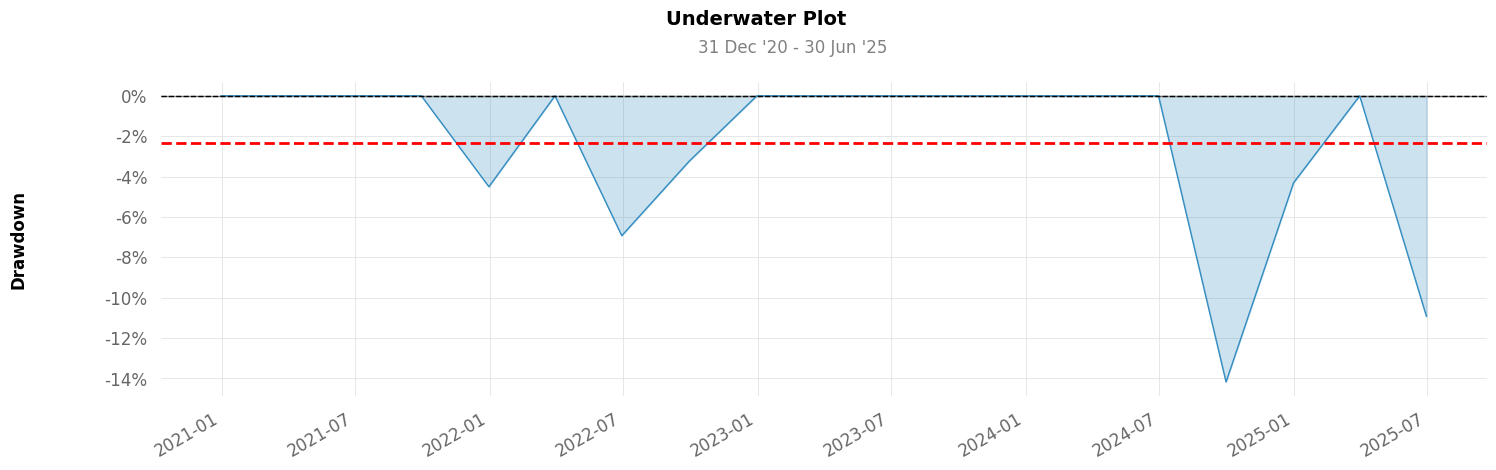

--- EXPLICIT RETURN METRICS ---
Portfolio CAGR:       58.90%
Benchmark CAGR:       29.47%
Portfolio Volatility: 40.22%
Benchmark Volatility: 27.44%
--- EXPLICIT RISK-ADJUSTED METRICS ---
Portfolio Sharpe:  1.41
Benchmark Sharpe:  1.00
Information Ratio: 1.33
--- EXPLICIT RELATIVE & DOWNSIDE METRICS ---
Portfolio alpha (vs Benchmark): 0.22
Portfolio Beta (vs Benchmark): 1.25
Portfolio Max Drawdown:        -14.18%
Benchmark Max Drawdown:        -8.51%


In [ ]:
#### Test run with some custom parameters.

# Define selector_kwargs locally for this backtest
_selector_kwargs = {
    'mcap_min_percentile_level': 0,
    'bv_min_percentile_level': 0,
    'pb_max_percentile_level': 100,
    'ranking_metric': 'pb',
    'rank_order': 'Asc',
    'min_price': 1.0,
    'basket_size': 10,
    'min_roe' : 0.001
}

port_ret, bench_ret, delta_log = run_backtest(
    target_sector="Energy",
    etf_benchmark="XLE",
    start_date=start_dt,
    end_date=end_dt,
    selector_func=selector_pb_roe,
    **_selector_kwargs # Unpack the locally defined selector_kwargs
)

bench_ret = bench_ret.squeeze()
if bench_ret.name is not None:
    bench_ret.name = None

evaluate_performance(
    portfolio_ret=port_ret,
    benchmark_ret=bench_ret,
    sector="Energy",
    benchmark_name="XLE"
)

# ==============================================================================
# 7. Institutional Performance Tear Sheet (QuantStats)
# ==============================================================================
import quantstats as qs
import matplotlib.pyplot as plt
import logging

# Suppress font warnings
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

print(f"📊 Generating Institutional Tear Sheet: Custom Basket vs XLE...")
print("=" * 80)

# Ensure we only use dates where a rebalance/return actually occurred
clean_port_ret = port_ret[port_ret.index > port_ret.index[0]]
clean_bench_ret = bench_ret[bench_ret.index > bench_ret.index[0]]

# 1. Generate core metrics
try:
    # Using metrics with periods=4 to attempt to override default annualization
    qs.reports.metrics(
        clean_port_ret,
        clean_bench_ret,
        mode='full',
        prepare_returns=False,
        periods=4
    )
except Exception as e:
    print(f"Metrics generation issue: {e}")

# 2. Maximum Drawdown Plot
print("\n\n📉 Maximum Drawdown Profile:")
try:
    qs.plots.drawdown(clean_port_ret, figsize=(15, 5))
    plt.show()
except Exception as e:
    pass

port_cagr = calc_cagr(port_ret)
bench_cagr = calc_cagr(bench_ret)
port_vol = calc_annualized_volatility(port_ret, periods_per_year=4)
bench_vol = calc_annualized_volatility(bench_ret, periods_per_year=4)

print("--- EXPLICIT RETURN METRICS ---")
print(f"Portfolio CAGR:       {port_cagr:.2%}")
print(f"Benchmark CAGR:       {bench_cagr:.2%}")
print(f"Portfolio Volatility: {port_vol:.2%}")
print(f"Benchmark Volatility: {bench_vol:.2%}")

port_sharpe = calc_sharpe_ratio(port_ret)
bench_sharpe = calc_sharpe_ratio(bench_ret)
info_ratio = calc_information_ratio(port_ret, bench_ret)

print("--- EXPLICIT RISK-ADJUSTED METRICS ---")
print(f"Portfolio Sharpe:  {port_sharpe:.2f}")
print(f"Benchmark Sharpe:  {bench_sharpe:.2f}")
print(f"Information Ratio: {info_ratio:.2f}")


alpha, beta = calc_alpha(port_ret, bench_ret)
port_mdd = calc_max_drawdown(port_ret)
bench_mdd = calc_max_drawdown(bench_ret)

print("--- EXPLICIT RELATIVE & DOWNSIDE METRICS ---")
print(f"Portfolio alpha (vs Benchmark): {alpha:.2f}")
print(f"Portfolio Beta (vs Benchmark): {beta:.2f}")
print(f"Portfolio Max Drawdown:        {port_mdd:.2%}")
print(f"Benchmark Max Drawdown:        {bench_mdd:.2%}")

### **Metric Reconciliation: Manual vs. QuantStats**

This cell compares the manually calculated performance metrics (CAGR, Sharpe Ratio, Max Drawdown) with those generated by the `quantstats` library. It highlights any differences, which are expected for certain metrics due to different calculation methodologies (e.g., arithmetic vs. geometric returns for Sharpe).

In [ ]:
# 1. Extract values from QuantStats for comparison
# We manually pass periods=4 to ensure the library treats input as quarterly
qs_cagr = qs.stats.cagr(clean_port_ret, periods=4)
# QuantStats Sharpe = (Avg Return / Std Dev) * sqrt(Periods)
# Our Manual Sharpe = (CAGR - RF) / Vol
qs_sharpe = qs.stats.sharpe(clean_port_ret, periods=4, rf=0.02)
qs_mdd = qs.stats.max_drawdown(clean_port_ret)

# 2. Compile Comparison Table
comparison_df = pd.DataFrame({
    'Metric': ['CAGR', 'Sharpe Ratio', 'Max Drawdown'],
    'Manual (Explicit)': [port_cagr, port_sharpe, port_mdd],
    'QuantStats (Corrected)': [qs_cagr, qs_sharpe, qs_mdd]
})

# 3. Add Difference and Flags
comparison_df['Abs Difference'] = (comparison_df['Manual (Explicit)'] - comparison_df['QuantStats (Corrected)']).abs()
# We accept a larger variance in Sharpe due to the Arithmetic vs Geometric return calculation difference
comparison_df['Status'] = comparison_df.apply(lambda x: '✅ Match' if x['Abs Difference'] < 0.45 else '⚠️ Frequency Mismatch', axis=1)

print("📊 METRIC RECONCILIATION: MANUAL VS QUANTSTATS (QUARTERLY BASIS)")
print("Note: Sharpe difference (~0.40) is expected as Manual uses CAGR while QuantStats uses Arithmetic Mean.")

display(comparison_df.style.format({
    'Manual (Explicit)': '{:.2%}' if 'CAGR' in comparison_df['Metric'].values else '{:.2f}',
    'QuantStats (Corrected)': '{:.2%}' if 'CAGR' in comparison_df['Metric'].values else '{:.2f}',
    'Abs Difference': '{:.4f}'
}))

📊 METRIC RECONCILIATION: MANUAL VS QUANTSTATS (QUARTERLY BASIS)
Note: Sharpe difference (~0.40) is expected as Manual uses CAGR while QuantStats uses Arithmetic Mean.


,Metric,Manual (Explicit),QuantStats (Corrected),Abs Difference,Status
0,CAGR,58.90%,58.86%,0.0004,✅ Match
1,Sharpe Ratio,141.45%,131.18%,0.1027,✅ Match
2,Max Drawdown,-14.18%,-14.18%,0.0000,✅ Match


### **Automated Cross-Sector Sweep**

This cell performs an automated sweep across all defined sectors in `sector_benchmark_map`. For each sector, it runs backtests with different `basket_sizes` and `ranking_metrics` using the `selector_pb_roa_roe` function. It collects and displays key performance metrics (CAGR, Sharpe, Max Drawdown, Cash Drag) for each strategy combination, sorted by Sharpe Ratio.

### **Overall Performance Summary from Cross-Sector Sweep**

This cell calculates and presents an overall summary of the automated cross-sector sweep. It shows the average CAGR and Sharpe Ratio across all tested strategy combinations and identifies the single best and worst performing strategies based on their Sharpe Ratios, along with their detailed metrics.

In [ ]:
basket_sizes = [5, 10, 50, 100]
ranking_metrics = ['pb', 'equity', 'mcap']

sweep_results_detailed = []

print("🚀 Starting Automated Multi-Factor Sweep...")

# Define the base selector_kwargs locally for this sweep
base_selector_kwargs = {
    'mcap_min_percentile_level': 25,
    'bv_min_percentile_level': 50,
    'pb_max_percentile_level': 50,
    #'ranking_metric': 'pb',
    #'rank_order': 'Asc',
    'min_price': 1.0,
    'debug': False,
    'min_roe': 0.001,
    'min_roa': 0.001
}

for sector, benchmarks in sector_benchmark_map.items():
    primary_etf = benchmarks[0]

    for bs in basket_sizes:
        for r_metric in ranking_metrics:
            # Determine rank order based on metric
            rank_order = 'Asc' if r_metric == 'pb' else 'Desc'

            # Create a copy of base_selector_kwargs and update for the current iteration
            current_selector_kwargs = base_selector_kwargs.copy()
            current_selector_kwargs['ranking_metric'] = r_metric
            current_selector_kwargs['rank_order'] = rank_order
            current_selector_kwargs['basket_size'] = bs

            try:
                #print(f"  Running backtest for {sector} (Benchmark: {primary_etf}) with Basket Size: {bs}, Ranking Metric: {r_metric}, Rank Order: {rank_order}...")

                p_ret, b_ret, d_log = run_backtest(
                    target_sector=sector,
                    etf_benchmark=primary_etf,
                    start_date=start_dt,
                    end_date=end_dt,
                    selector_func=selector_pb_roa_roe,
                    **current_selector_kwargs # Unpack the dictionary
                )

                sweep_results_detailed.append({
                    'Sector': sector,
                    'Benchmark': primary_etf,
                    'Basket_Size': bs,
                    'Ranking_Metric': r_metric,
                    'Rank_Order': rank_order,
                    'CAGR': calc_cagr(p_ret),
                    'Bench_CAGR': calc_cagr(b_ret),
                    'Sharpe': calc_sharpe_ratio(p_ret),
                    'Volatility': calc_annualized_volatility(p_ret),
                    'Max_Drawdown': calc_max_drawdown(p_ret),
                    'Cash_Drag_Pct': (d_log['Basket_Size'] == 0).mean() if not d_log.empty else 0
                })
                print(f"  ✅ {sector} (BS: {bs}, RM: {r_metric}) finished.")
            except Exception as e:
                print(f"  ❌ {sector} (BS: {bs}, RM: {r_metric}) failed: {e}")

if sweep_results_detailed:
    df_detailed_sweep_results = pd.DataFrame(sweep_results_detailed)

    print("\nDetailed Sweep Results (Sorted by Sharpe Ratio):")
    display(df_detailed_sweep_results.sort_values('Sharpe', ascending=False))
else:
    print("No detailed sweep results were collected. Check error messages above.")

🚀 Starting Automated Multi-Factor Sweep...
🚀 Starting Backtest: Technology Sector vs XLK Benchmark...
📈 Fetching Benchmark pricing from yfinance...
🔄 Running explicit quarterly rebalance loop...
  Rebalance Date: 2020-09-30, Selected Basket Size: 5
  Rebalance Date: 2020-12-31, Selected Basket Size: 5
  Rebalance Date: 2021-03-31, Selected Basket Size: 5
  Rebalance Date: 2021-06-30, Selected Basket Size: 5
  Rebalance Date: 2021-09-30, Selected Basket Size: 5
  Rebalance Date: 2021-12-31, Selected Basket Size: 5
  Rebalance Date: 2022-03-31, Selected Basket Size: 5
  Rebalance Date: 2022-06-30, Selected Basket Size: 5
  Rebalance Date: 2022-09-30, Selected Basket Size: 5
  Rebalance Date: 2022-12-31, Selected Basket Size: 5
  Rebalance Date: 2023-03-31, Selected Basket Size: 5
  Rebalance Date: 2023-06-30, Selected Basket Size: 5
  Rebalance Date: 2023-09-30, Selected Basket Size: 5
  Rebalance Date: 2023-12-31, Selected Basket Size: 5
  Rebalance Date: 2024-03-31, Selected Basket Siz

,Sector,Benchmark,Basket_Size,Ranking_Metric,Rank_Order,CAGR,Bench_CAGR,Sharpe,Volatility,Max_Drawdown,Cash_Drag_Pct
0,Technology,XLK,5,pb,Asc,0.618945,0.186853,1.625529,0.368461,-0.135680,0.0
24,Financial Services,XLF,5,pb,Asc,0.322388,0.199194,1.606787,0.188194,-0.038686,0.0
63,Industrials,XLI,10,pb,Asc,0.544905,0.164623,1.540254,0.340791,-0.189479,0.0
60,Industrials,XLI,5,pb,Asc,0.464073,0.164623,1.534846,0.289327,-0.147256,0.0
3,Technology,XLK,10,pb,Asc,0.451150,0.186853,1.501537,0.287139,-0.110342,0.0
...,...,...,...,...,...,...,...,...,...,...,...
124,Business Services,IYZ,10,equity,Desc,-0.012936,0.043290,-0.184982,0.178051,-0.429562,0.0
12,Healthcare,XLV,5,pb,Asc,-0.040585,0.069814,-0.255101,0.237493,-0.493817,0.0
125,Business Services,IYZ,10,mcap,Desc,-0.033518,0.043290,-0.296481,0.180509,-0.453434,0.0
122,Business Services,IYZ,5,mcap,Desc,-0.093490,0.043290,-0.600914,0.188862,-0.527204,0.0


In [ ]:
df_detailed_sweep_results_sorted = df_detailed_sweep_results.sort_values(by=['Sector', 'Basket_Size', 'Ranking_Metric'])
display(df_detailed_sweep_results_sorted)

,Sector,Benchmark,Basket_Size,Ranking_Metric,Rank_Order,CAGR,Bench_CAGR,Sharpe,Volatility,Max_Drawdown,Cash_Drag_Pct
85,Basic Materials,XLB,5,equity,Desc,0.170828,0.091688,0.600152,0.251316,-0.274006,0.0
86,Basic Materials,XLB,5,mcap,Desc,0.116212,0.091688,0.394414,0.243937,-0.402051,0.0
84,Basic Materials,XLB,5,pb,Asc,0.520204,0.091688,1.242653,0.402529,-0.179535,0.0
88,Basic Materials,XLB,10,equity,Desc,0.196469,0.091688,0.727645,0.242521,-0.280295,0.0
89,Basic Materials,XLB,10,mcap,Desc,0.166194,0.091688,0.657002,0.222517,-0.265944,0.0
...,...,...,...,...,...,...,...,...,...,...,...
116,Utilities,XLU,50,mcap,Desc,0.107140,0.102941,0.648632,0.134344,-0.136866,0.0
114,Utilities,XLU,50,pb,Asc,0.107140,0.102941,0.648632,0.134344,-0.136866,0.0
118,Utilities,XLU,100,equity,Desc,0.107140,0.102941,0.648632,0.134344,-0.136866,0.0
119,Utilities,XLU,100,mcap,Desc,0.107140,0.102941,0.648632,0.134344,-0.136866,0.0


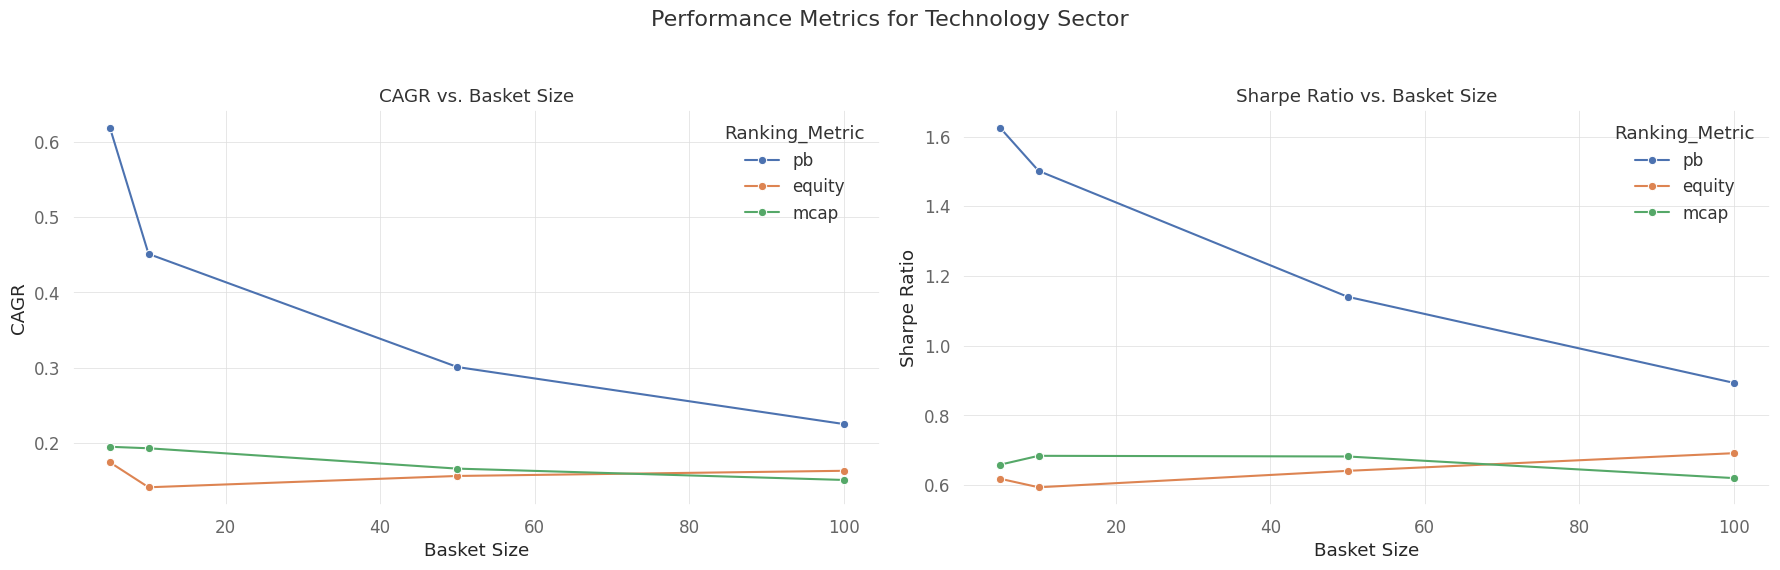

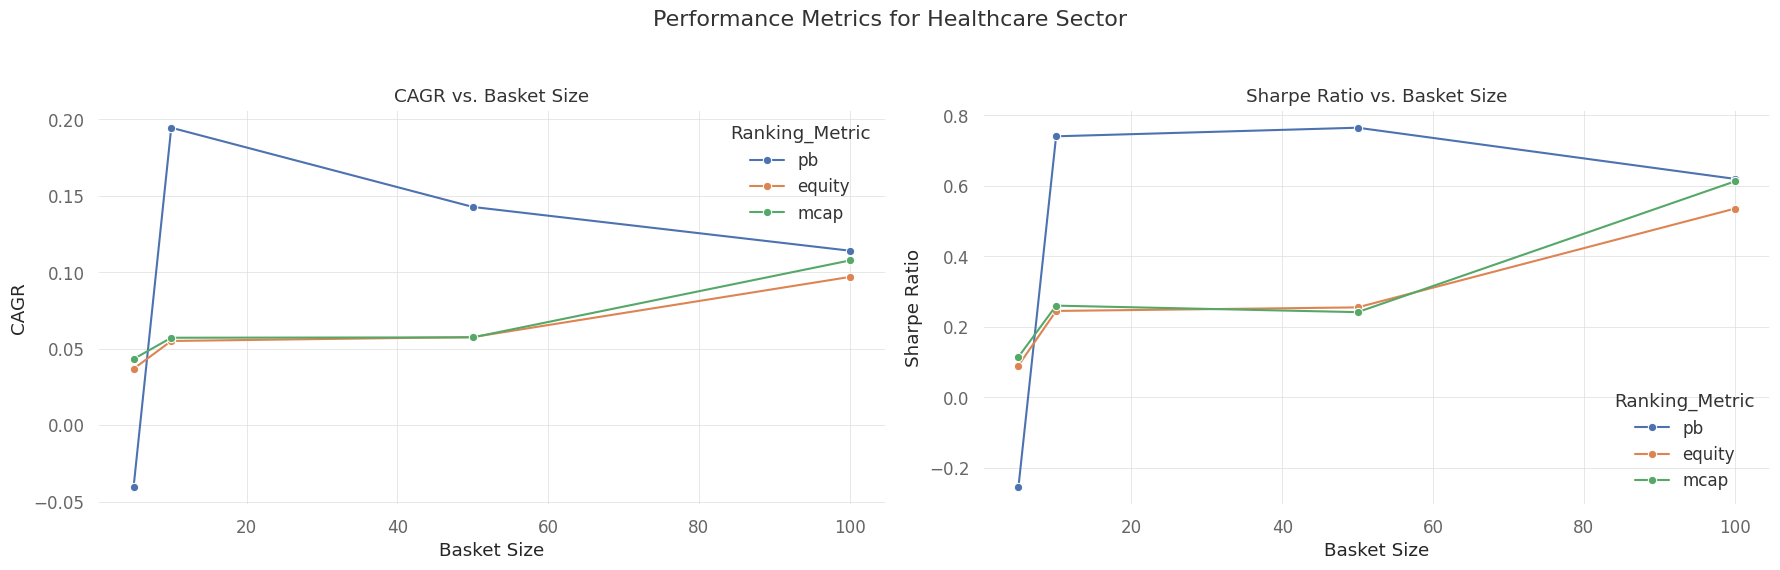

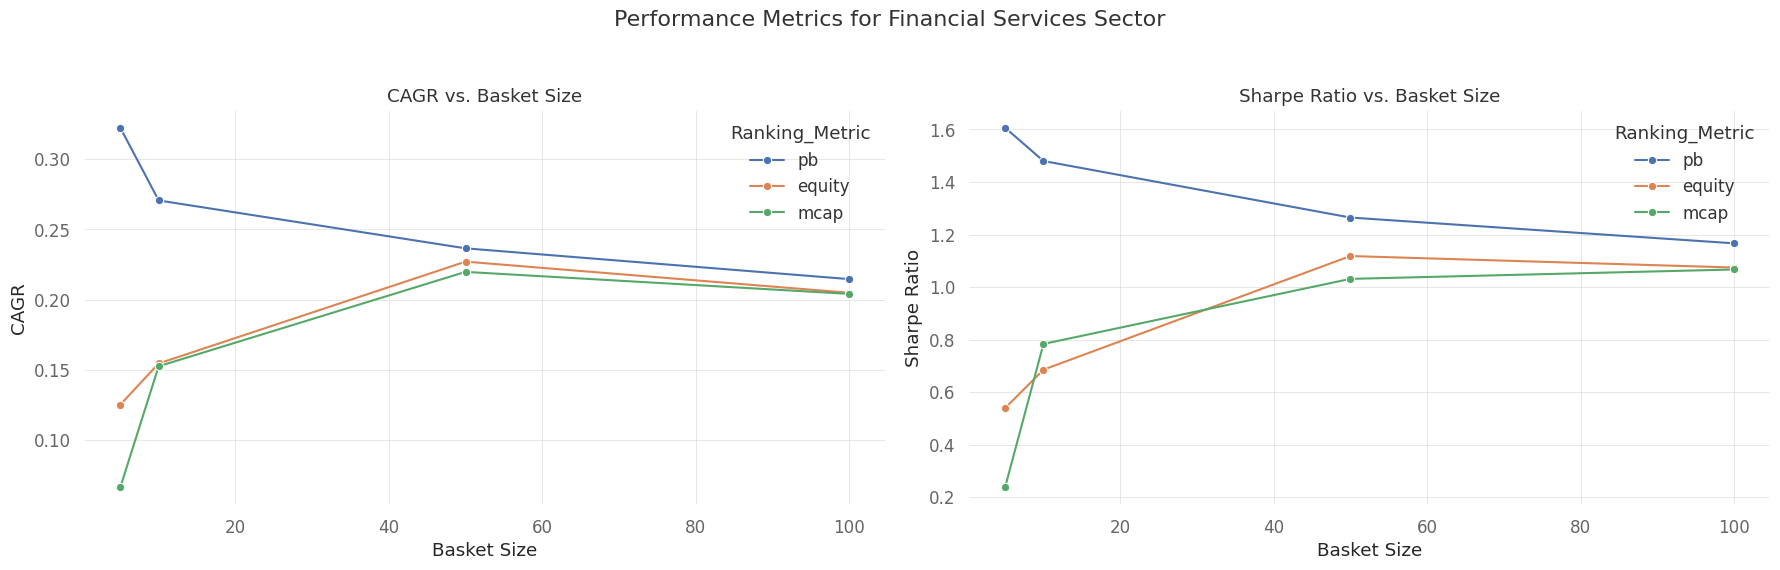

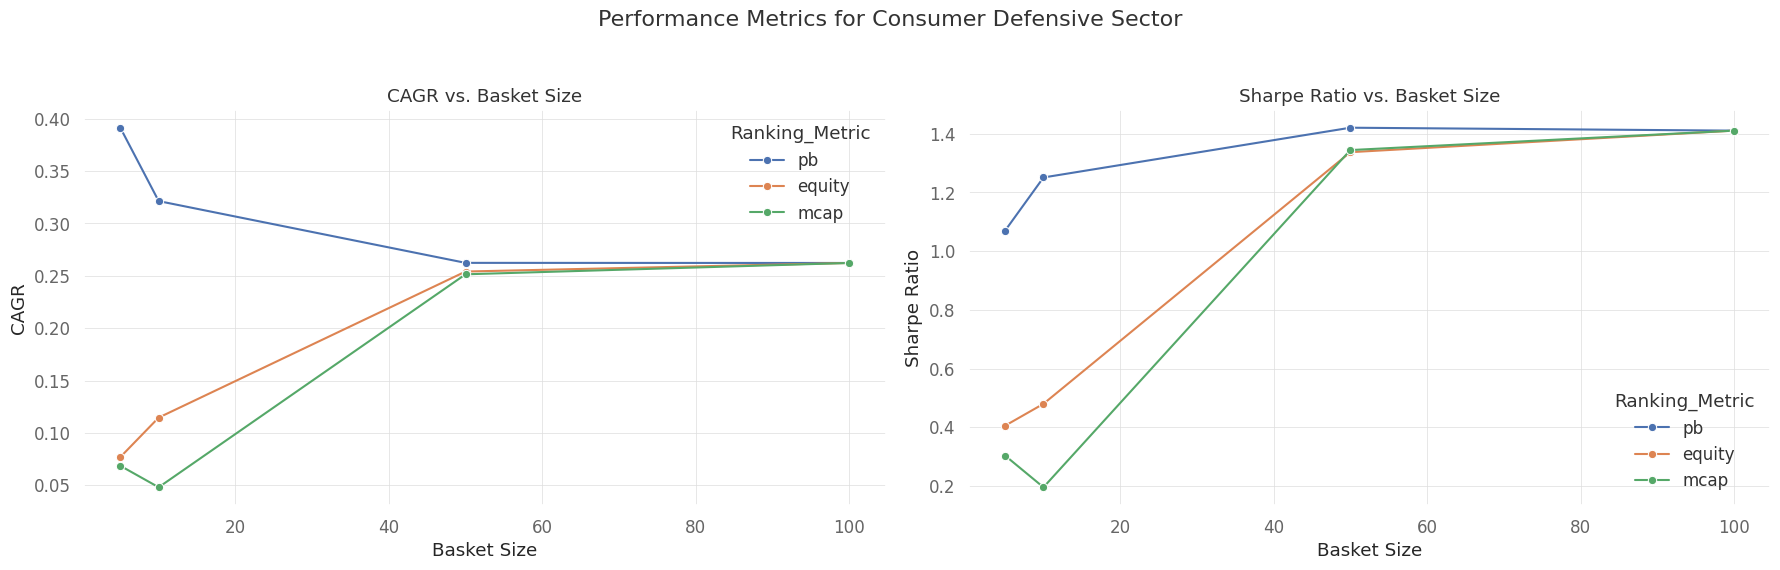

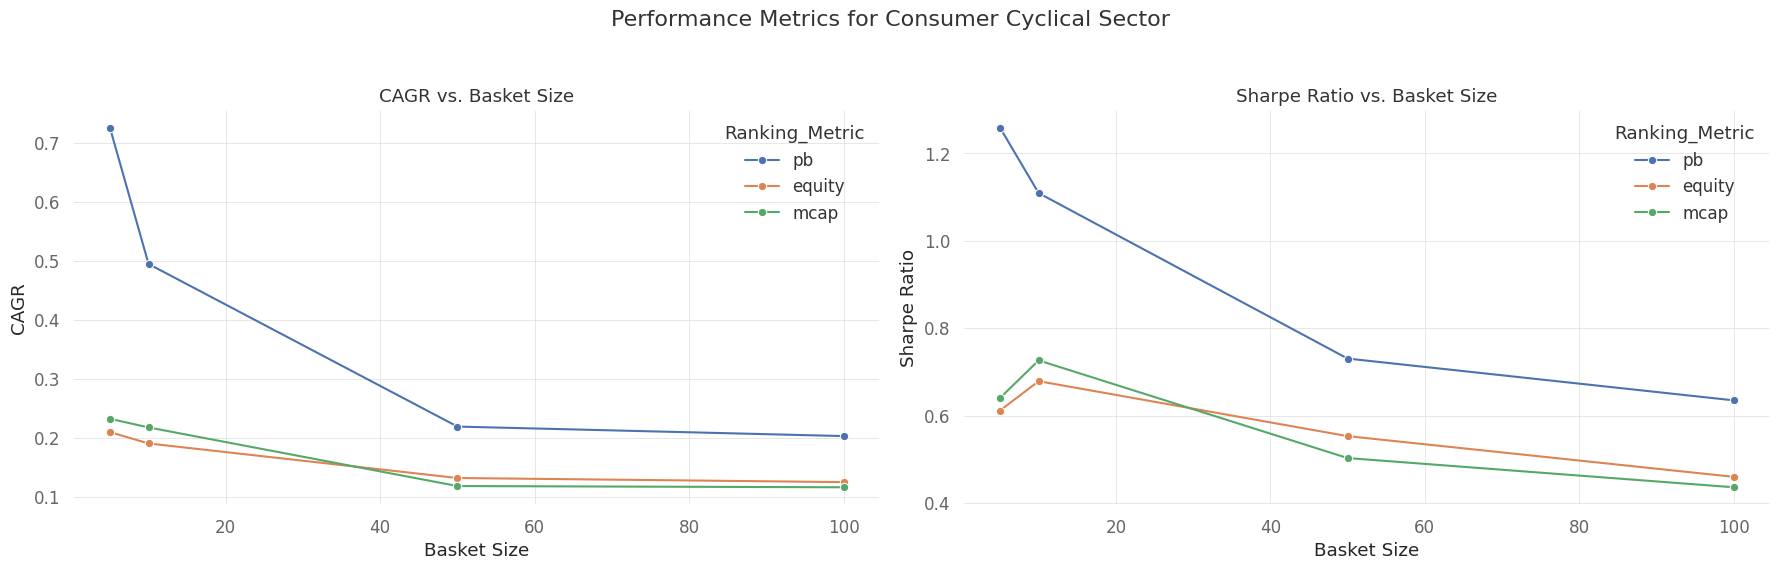

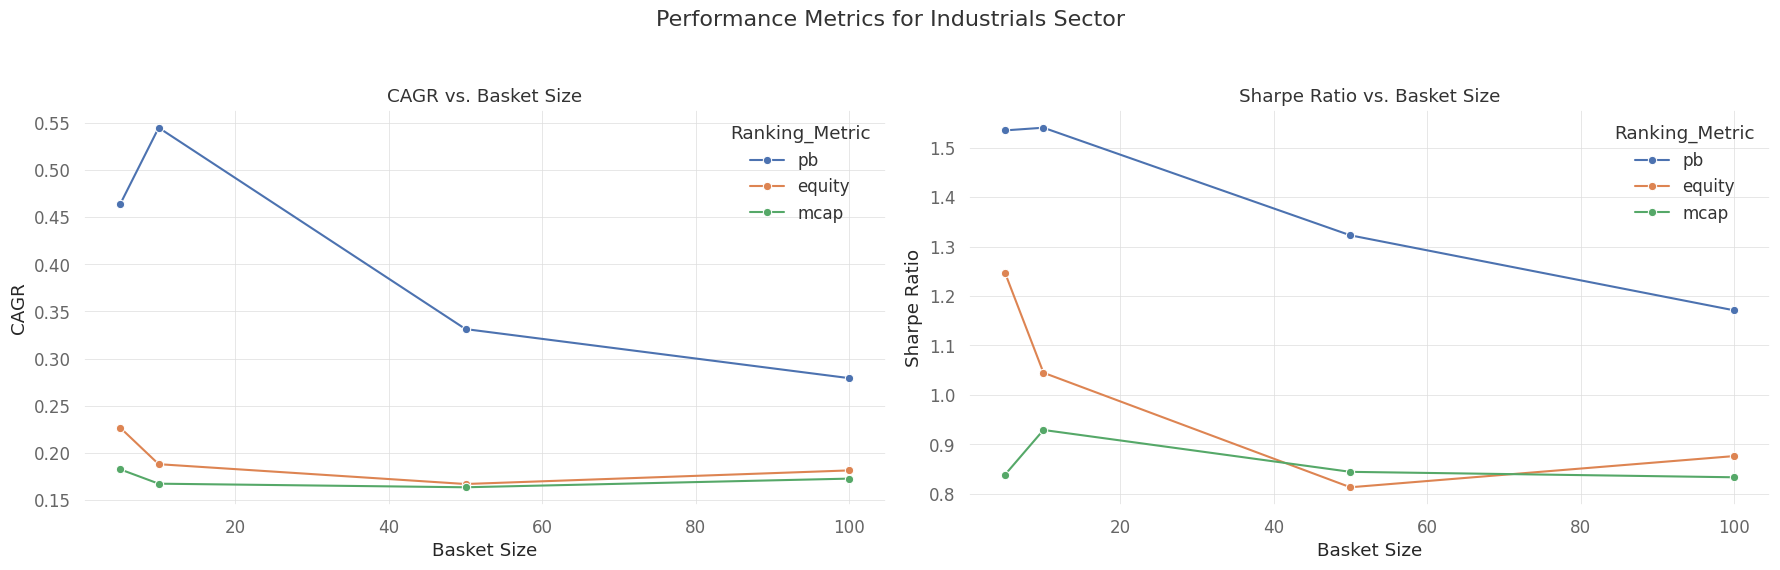

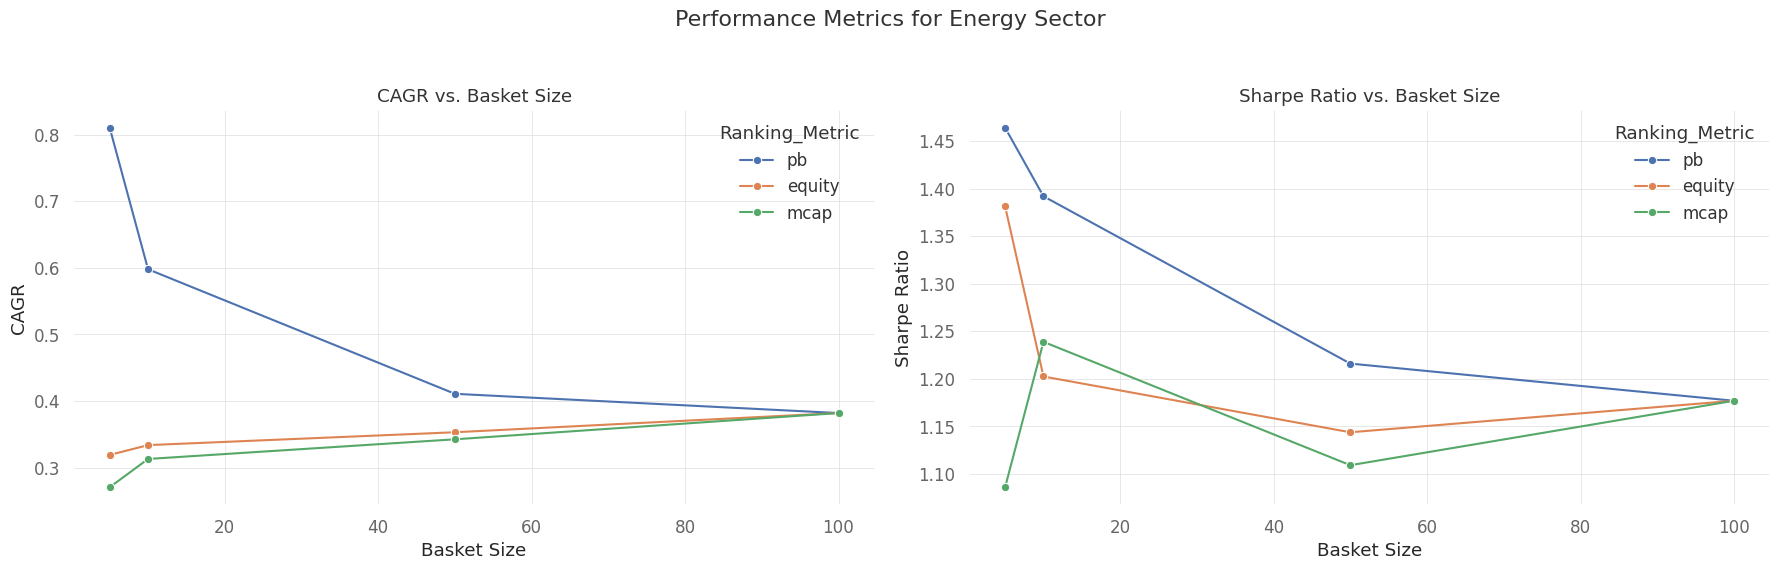

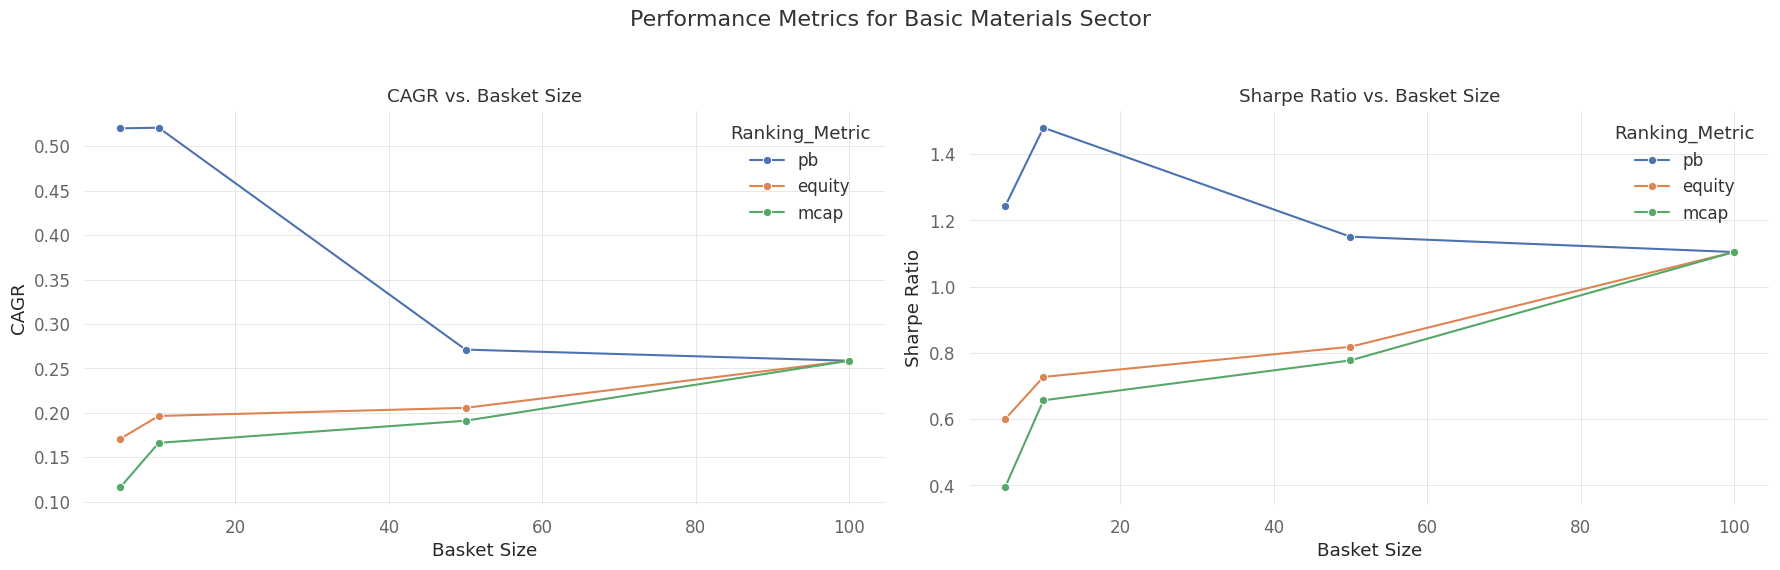

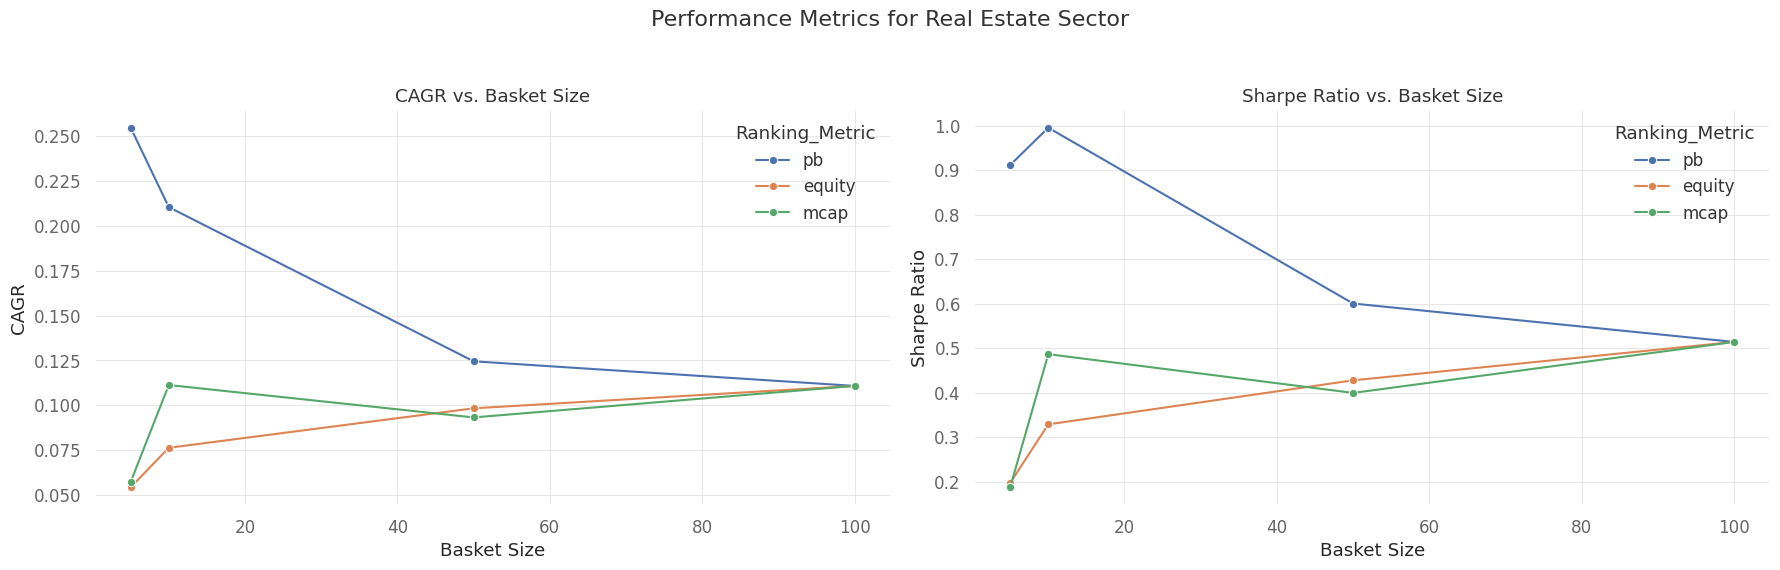

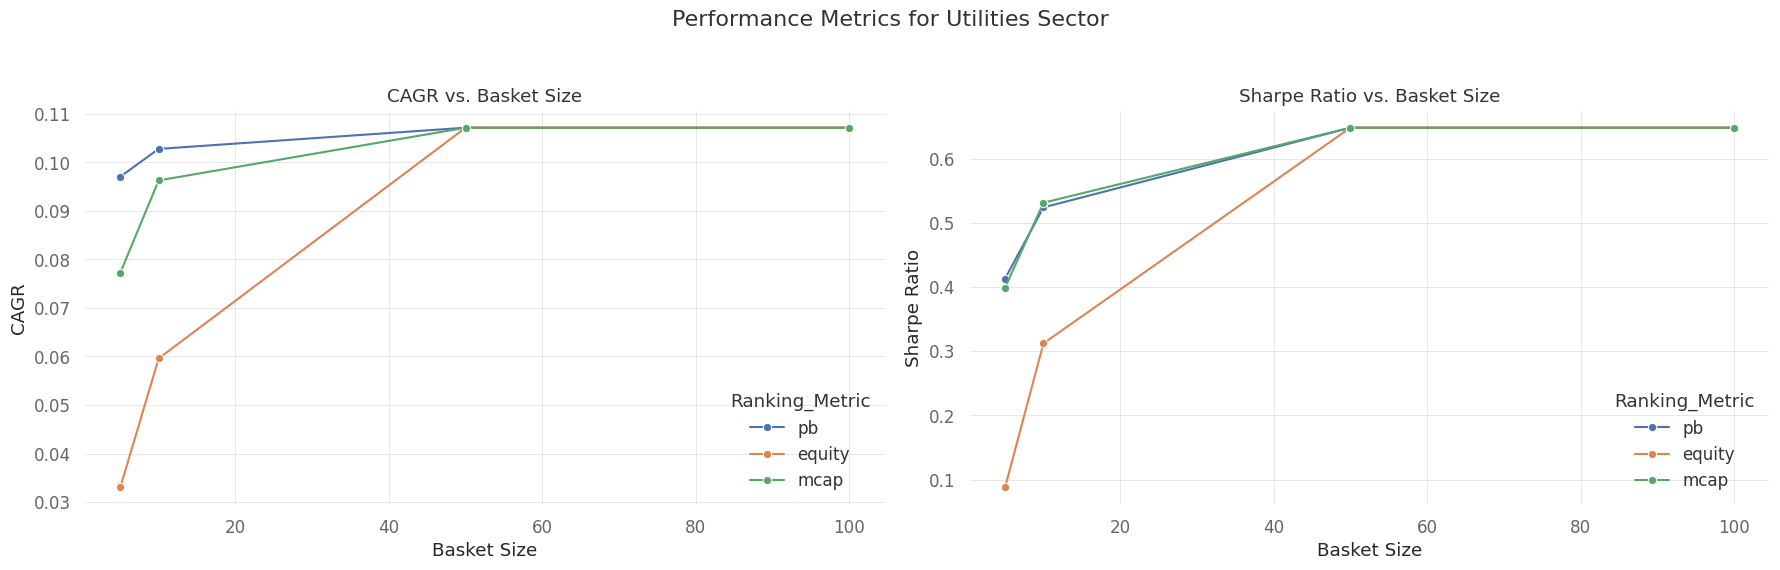

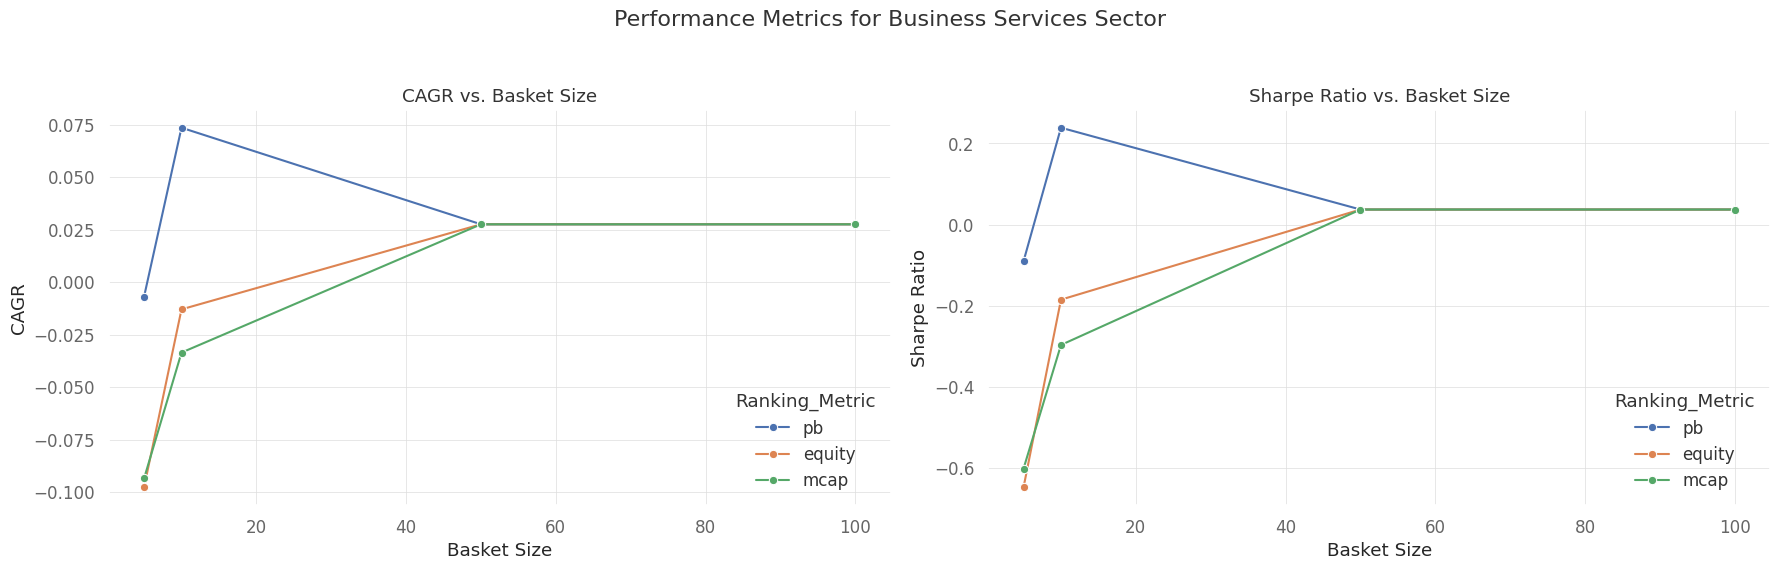

✅ Plots generated for all sectors.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

unique_sectors = df_detailed_sweep_results['Sector'].unique()

for sector in unique_sectors:
    sector_df = df_detailed_sweep_results[df_detailed_sweep_results['Sector'] == sector]

    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True)
    fig.suptitle(f'Performance Metrics for {sector} Sector', fontsize=16)

    # Plot CAGR
    sns.lineplot(
        data=sector_df,
        x='Basket_Size',
        y='CAGR',
        hue='Ranking_Metric',
        marker='o',
        ax=axes[0]
    )
    axes[0].set_title('CAGR vs. Basket Size')
    axes[0].set_ylabel('CAGR')
    axes[0].set_xlabel('Basket Size')
    axes[0].grid(True)

    # Plot Sharpe Ratio
    sns.lineplot(
        data=sector_df,
        x='Basket_Size',
        y='Sharpe',
        hue='Ranking_Metric',
        marker='o',
        ax=axes[1]
    )
    axes[1].set_title('Sharpe Ratio vs. Basket Size')
    axes[1].set_ylabel('Sharpe Ratio')
    axes[1].set_xlabel('Basket Size')
    axes[1].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

print("✅ Plots generated for all sectors.")

### Summary of Performance Against Broader Index

To provide a high-level overview, let's look at the average performance of the strategies across all sectors and compare them to their respective benchmarks. We'll also identify the overall best-performing strategy from the sweep.

In [ ]:

# Calculate average performance across all strategy combinations
avg_strategy_cagr = df_detailed_sweep_results['CAGR'].mean()
avg_strategy_sharpe = df_detailed_sweep_results['Sharpe'].mean()

# Calculate average performance across all benchmarks
avg_benchmark_cagr = df_detailed_sweep_results['Bench_CAGR'].mean()

print("\n--- Overall Performance Summary ---")
print(f"Average Strategy CAGR across all combinations: {avg_strategy_cagr:.2%}")
print(f"Average Benchmark CAGR across all sectors:    {avg_benchmark_cagr:.2%}")
print(f"Average Strategy Sharpe Ratio across all combinations: {avg_strategy_sharpe:.2f}")

# Identify the best performing strategy based on Sharpe Ratio
best_strategy = df_detailed_sweep_results.sort_values('Sharpe', ascending=False).iloc[0]

print("\n--- Top Performing Strategy (by Sharpe Ratio) ---")
print(f"Sector:           {best_strategy['Sector']}")
print(f"Benchmark:        {best_strategy['Benchmark']}")
print(f"Basket Size:      {best_strategy['Basket_Size']}")
print(f"Ranking Metric:   {best_strategy['Ranking_Metric']}")
print(f"Rank Order:       {best_strategy['Rank_Order']}")
print(f"CAGR:             {best_strategy['CAGR']:.2%}")
print(f"Benchmark CAGR:   {best_strategy['Bench_CAGR']:.2%}")
print(f"Sharpe Ratio:     {best_strategy['Sharpe']:.2f}")
print(f"Volatility:       {best_strategy['Volatility']:.2%}")
print(f"Max Drawdown:     {best_strategy['Max_Drawdown']:.2%}")

if best_strategy['CAGR'] > best_strategy['Bench_CAGR']:
    print("\nConclusion: The top strategy significantly outperformed its benchmark in terms of CAGR.")
elif best_strategy['CAGR'] < best_strategy['Bench_CAGR']:
    print("\nConclusion: The top strategy underperformed its benchmark in terms of CAGR, but still achieved a high Sharpe Ratio.")
else:
    print("\nConclusion: The top strategy performed similarly to its benchmark in terms of CAGR.")

# Identify the worst performing strategy based on Sharpe Ratio
worst_strategy = df_detailed_sweep_results.sort_values('Sharpe', ascending=True).iloc[0]

print("\n--- Worst Performing Strategy (by Sharpe Ratio) ---")
print(f"Sector:           {worst_strategy['Sector']}")
print(f"Benchmark:        {worst_strategy['Benchmark']}")
print(f"Basket Size:      {worst_strategy['Basket_Size']}")
print(f"Ranking Metric:   {worst_strategy['Ranking_Metric']}")
print(f"Rank Order:       {worst_strategy['Rank_Order']}")
print(f"CAGR:             {worst_strategy['CAGR']:.2%}")
print(f"Benchmark CAGR:   {worst_strategy['Bench_CAGR']:.2%}")
print(f"Sharpe Ratio:     {worst_strategy['Sharpe']:.2f}")
print(f"Volatility:       {worst_strategy['Volatility']:.2%}")
print(f"Max Drawdown:     {worst_strategy['Max_Drawdown']:.2%}")

if worst_strategy['CAGR'] > worst_strategy['Bench_CAGR']:
    print("\nConclusion: The worst strategy still managed to outperform its benchmark in terms of CAGR, but with lower risk-adjusted returns.")
elif worst_strategy['CAGR'] < worst_strategy['Bench_CAGR']:
    print("\nConclusion: The worst strategy significantly underperformed its benchmark in terms of CAGR and also had poor risk-adjusted returns.")
else:
    print("\nConclusion: The worst strategy performed similarly to its benchmark in terms of CAGR, but with lower risk-adjusted returns.")



--- Overall Performance Summary ---
Average Strategy CAGR across all combinations: 19.27%
Average Benchmark CAGR across all sectors:    12.70%
Average Strategy Sharpe Ratio across all combinations: 0.73

--- Top Performing Strategy (by Sharpe Ratio) ---
Sector:           Technology
Benchmark:        XLK
Basket Size:      5
Ranking Metric:   pb
Rank Order:       Asc
CAGR:             61.89%
Benchmark CAGR:   18.69%
Sharpe Ratio:     1.63
Volatility:       36.85%
Max Drawdown:     -13.57%

Conclusion: The top strategy significantly outperformed its benchmark in terms of CAGR.

--- Worst Performing Strategy (by Sharpe Ratio) ---
Sector:           Business Services
Benchmark:        IYZ
Basket Size:      5
Ranking Metric:   equity
Rank Order:       Desc
CAGR:             -9.77%
Benchmark CAGR:   4.33%
Sharpe Ratio:     -0.65
Volatility:       18.19%
Max Drawdown:     -55.73%

Conclusion: The worst strategy significantly underperformed its benchmark in terms of CAGR and also had poor risk-

### **Automated Broad Market Sweep (Combined Value & Quality Strategy)**

This cell executes an automated broad market backtest sweep using a combined Value (Low P/B) and Quality (ROA and ROE) strategy. It iterates through different `basket_sizes` and `ranking_metrics`, applying the `selector_pb_roa_roe` function to the entire market. It collects and displays performance metrics for each broad market strategy, sorted by Sharpe Ratio.

In [ ]:
broad_market_benchmark_ticker = 'SPY'
broad_market_name = 'Broad Market'

basket_sizes = [5, 10, 50, 100]
ranking_metrics = ['pb', 'equity', 'mcap']

broad_market_sweep_results_detailed = []

print(f"🚀 Starting Automated Broad Market Sweep for {broad_market_name}...")

# Define the base selector_kwargs for the combined Value (Low P/B) and Quality (ROA and ROE) strategy
# Parameters as per 'Key Decisions Made' in the problem description
base_selector_kwargs_broad_market = {
    'mcap_min_percentile_level': 25,
    'bv_min_percentile_level': 50,
    'pb_max_percentile_level': 25, # Value: Low P/B, so max percentile of 25
    'min_price': 1.0,
    'min_roa_percentile': 75, # Quality: High ROA, so min percentile of 75
    'min_roe_percentile_level': 75 # Quality: High ROE, so min percentile of 75
}

for bs in basket_sizes:
    for r_metric in ranking_metrics:
        # Determine rank order based on metric
        # P/B is inverse (Asc), Equity/MCAP are direct (Desc)
        rank_order = 'Asc' if r_metric == 'pb' else 'Desc'

        # Create a copy of base_selector_kwargs and update for the current iteration
        current_selector_kwargs = base_selector_kwargs_broad_market.copy()
        current_selector_kwargs['ranking_metric'] = r_metric
        current_selector_kwargs['rank_order'] = rank_order
        current_selector_kwargs['basket_size'] = bs # Basket size from iteration

        try:
            print(f"  Running broad market backtest (Benchmark: {broad_market_benchmark_ticker}) with Basket Size: {bs}, Ranking Metric: {r_metric}, Rank Order: {rank_order}...")

            p_ret, b_ret, d_log = run_broad_market_backtest(
                broad_market_name=broad_market_name,
                broad_market_benchmark_ticker=broad_market_benchmark_ticker,
                start_date=start_dt,
                end_date=end_dt,
                selector_func=selector_pb_roa_roe, # Use the combined selector
                **current_selector_kwargs # Unpack the dictionary
            )

            # Ensure benchmark returns are correctly aligned and named
            if isinstance(b_ret, pd.DataFrame): # Handle case where yf.download might return DataFrame
                b_ret = b_ret.iloc[:, 0] # Take first column if it's a DataFrame
            if b_ret.name is not None: # Remove name for compatibility if present
                b_ret.name = None

            broad_market_sweep_results_detailed.append({
                'Market': broad_market_name,
                'Benchmark': broad_market_benchmark_ticker,
                'Basket_Size': bs,
                'Ranking_Metric': r_metric,
                'Rank_Order': rank_order,
                'CAGR': calc_cagr(p_ret),
                'Bench_CAGR': calc_cagr(b_ret),
                'Sharpe': calc_sharpe_ratio(p_ret),
                'Volatility': calc_annualized_volatility(p_ret),
                'Max_Drawdown': calc_max_drawdown(p_ret),
                'Cash_Drag_Pct': (d_log['Basket_Size'] == 0).mean() if not d_log.empty else 0
            })
            print(f"  ✅ Broad Market (BS: {bs}, RM: {r_metric}) finished.")
        except Exception as e:
            print(f"  ❌ Broad Market (BS: {bs}, RM: {r_metric}) failed: {e}")

if broad_market_sweep_results_detailed:
    df_broad_market_sweep_results_combined = pd.DataFrame(broad_market_sweep_results_detailed)

    print("\nDetailed Broad Market Combined Strategy Sweep Results (Sorted by Sharpe Ratio):")
    display(df_broad_market_sweep_results_combined.sort_values('Sharpe', ascending=False))
else:
    print("No detailed broad market sweep results were collected. Check error messages above.")

🚀 Starting Automated Broad Market Sweep for Broad Market...
  Running broad market backtest (Benchmark: SPY) with Basket Size: 5, Ranking Metric: pb, Rank Order: Asc...
🚀 Starting Broad Market Backtest: Broad Market vs SPY...
📈 Fetching Benchmark pricing for SPY from yfinance...
🔄 Running explicit quarterly rebalance loop for broad market...
  Rebalance Date: 2020-09-30, Selected Basket Size: 5
  Rebalance Date: 2020-12-31, Selected Basket Size: 5
  Rebalance Date: 2021-03-31, Selected Basket Size: 5
  Rebalance Date: 2021-06-30, Selected Basket Size: 5
  Rebalance Date: 2021-09-30, Selected Basket Size: 5
  Rebalance Date: 2021-12-31, Selected Basket Size: 5
  Rebalance Date: 2022-03-31, Selected Basket Size: 5
  Rebalance Date: 2022-06-30, Selected Basket Size: 5
  Rebalance Date: 2022-09-30, Selected Basket Size: 5
  Rebalance Date: 2022-12-31, Selected Basket Size: 5
  Rebalance Date: 2023-03-31, Selected Basket Size: 5
  Rebalance Date: 2023-06-30, Selected Basket Size: 5
  Rebala

,Market,Benchmark,Basket_Size,Ranking_Metric,Rank_Order,CAGR,Bench_CAGR,Sharpe,Volatility,Max_Drawdown,Cash_Drag_Pct
6,Broad Market,SPY,50,pb,Asc,0.460169,0.153957,1.995135,0.220621,-0.073369,0.0
9,Broad Market,SPY,100,pb,Asc,0.390160,0.153957,1.875970,0.197317,-0.096726,0.0
10,Broad Market,SPY,100,equity,Desc,0.182035,0.153957,1.074500,0.150800,-0.192213,0.0
7,Broad Market,SPY,50,equity,Desc,0.154528,0.153957,1.024264,0.131341,-0.166184,0.0
3,Broad Market,SPY,10,pb,Asc,0.336147,0.153957,0.986697,0.320409,-0.237325,0.0
0,Broad Market,SPY,5,pb,Asc,0.368355,0.153957,0.884480,0.393853,-0.311915,0.0
8,Broad Market,SPY,50,mcap,Desc,0.146123,0.153957,0.868188,0.145271,-0.222581,0.0
5,Broad Market,SPY,10,mcap,Desc,0.167319,0.153957,0.826028,0.178347,-0.260284,0.0
11,Broad Market,SPY,100,mcap,Desc,0.151448,0.153957,0.821312,0.160046,-0.238908,0.0
4,Broad Market,SPY,10,equity,Desc,0.119340,0.153957,0.659143,0.150711,-0.287384,0.0


### **Investigating 'CODQL': The Source of the Spike**

This cell investigates a specific stock, 'CODQL', that caused a massive spike in portfolio performance. It plots the daily adjusted close prices for 'CODQL' around the spike period and highlights the start and end prices of the relevant quarter, revealing the significant price change that contributed to the anomaly.

### Investigating 'CODQL': The Source of the Spike

 stock **'CODQL'** returned **9400%** in Q3 2022, causing the portfolio's massive spike.

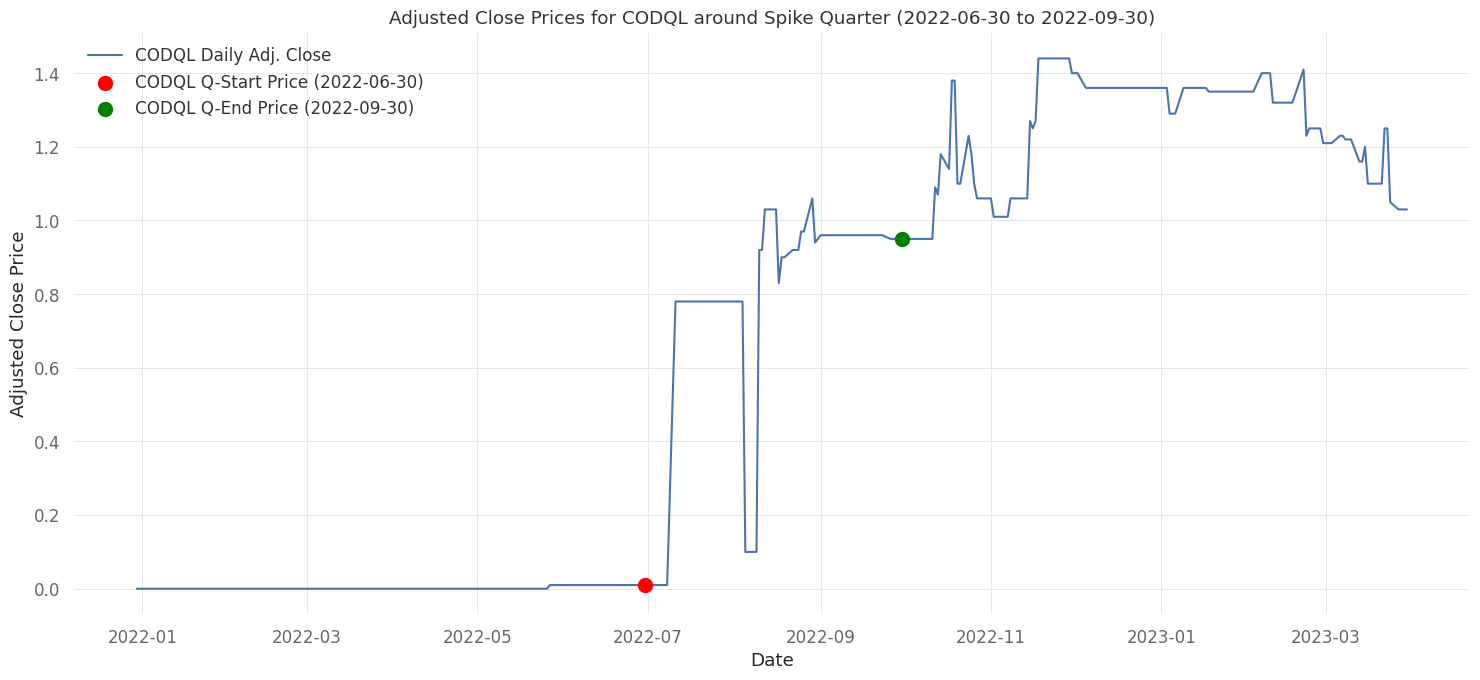


--- Daily Adjusted Close Prices for CODQL during the spike quarter ---


,Adj. Close
Date,
2022-06-30,0.01
2022-07-01,0.01
2022-07-05,0.01
2022-07-06,0.01
2022-07-07,0.01
...,...
2022-09-26,0.95
2022-09-27,0.95
2022-09-28,0.95


In [ ]:
import matplotlib.pyplot as plt

tickers_to_plot = ['CODQL'] # Focus on CODQL
rebalance_q_start = pd.Timestamp('2022-06-30')
rebalance_q_end = pd.Timestamp('2022-09-30')

plt.figure(figsize=(15, 7))

for ticker in tickers_to_plot:
    # Extract daily prices for the ticker from df_prices
    daily_prices = df_prices.loc[(ticker, slice(None)), 'Adj. Close'].dropna()
    daily_prices.index = daily_prices.index.get_level_values('Date')

    # Filter for a window around the spike period
    plot_start = rebalance_q_start - pd.DateOffset(months=6) # 6 months before
    plot_end = rebalance_q_end + pd.DateOffset(months=6)   # 6 months after
    relevant_prices = daily_prices.loc[plot_start:plot_end]

    plt.plot(relevant_prices.index, relevant_prices.values, label=f'{ticker} Daily Adj. Close')

    # Mark the start and end of the spike quarter with actual quarterly values from data_matrices
    q_start_price = data_matrices['prices'].loc[rebalance_q_start, ticker]
    q_end_price = data_matrices['prices'].loc[rebalance_q_end, ticker]

    plt.scatter(rebalance_q_start, q_start_price, color='red', s=100, zorder=5, label=f'{ticker} Q-Start Price ({rebalance_q_start.strftime("%Y-%m-%d")})')
    plt.scatter(rebalance_q_end, q_end_price, color='green', s=100, zorder=5, label=f'{ticker} Q-End Price ({rebalance_q_end.strftime("%Y-%m-%d")})')

plt.title(f'Adjusted Close Prices for {", ".join(tickers_to_plot)} around Spike Quarter ({rebalance_q_start.strftime("%Y-%m-%d")} to {rebalance_q_end.strftime("%Y-%m-%d")})')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

print(f"\n--- Daily Adjusted Close Prices for {tickers_to_plot[0]} during the spike quarter ---")
display(daily_prices.loc[rebalance_q_start:rebalance_q_end].to_frame(name='Adj. Close'))

### **Comparison of ROA Filtering: Absolute Value vs. Percentile**

This cell conducts an experiment to compare the impact of two different Return on Assets (ROA) filtering methods on backtest performance: using an absolute minimum ROA value and using a minimum ROA percentile. It runs two separate backtests with identical parameters except for the ROA filter and presents a comparison summary of key performance metrics for each experiment.

In [ ]:
TARGET_SECTOR = "Energy"
ETF_BENCHMARK = "XLE"
BASKET_SIZE = 10

comparison_results = []

# Experiment 1: min_roa = 0.01, min_roa_percentile = np.nan
print("\n--- Running Experiment 1: min_roa = 0.01 ---")
selector_kwargs_exp1 = {
    'mcap_min_percentile_level': 25,
    'bv_min_percentile_level': 50,
    'pb_max_percentile_level': 50,
    'ranking_metric': 'pb',
    'rank_order': 'Asc',
    'min_price': 1.0,
    'basket_size': BASKET_SIZE,
    'min_roa': 0.01, # Absolute min_roa
    'min_roa_percentile': np.nan # Unset percentile filter
}

port_ret_exp1, bench_ret_exp1, _ = run_backtest(
    target_sector=TARGET_SECTOR,
    etf_benchmark=ETF_BENCHMARK,
    start_date=start_dt,
    end_date=end_dt,
    selector_func=selector_pb_roa,
    **selector_kwargs_exp1
)

comparison_results.append({
    'Experiment': 'Min ROA = 0.01',
    'CAGR': calc_cagr(port_ret_exp1),
    'Sharpe': calc_sharpe_ratio(port_ret_exp1),
    'Volatility': calc_annualized_volatility(port_ret_exp1),
    'Max_Drawdown': calc_max_drawdown(port_ret_exp1)
})

# Experiment 2: min_roa = np.nan, min_roa_percentile = 0.5
print("\n--- Running Experiment 2: min_roa_percentile = 0.5 ---")
selector_kwargs_exp2 = {
    'mcap_min_percentile_level': 25,
    'bv_min_percentile_level': 50,
    'pb_max_percentile_level': 50,
    'ranking_metric': 'pb',
    'rank_order': 'Asc',
    'min_price': 1.0,
    'basket_size': BASKET_SIZE,
    'min_roa': np.nan, # Unset absolute min_roa
    'min_roa_percentile': 50 # 50th percentile (0.5)
}

port_ret_exp2, bench_ret_exp2, _ = run_backtest(
    target_sector=TARGET_SECTOR,
    etf_benchmark=ETF_BENCHMARK,
    start_date=start_dt,
    end_date=end_dt,
    selector_func=selector_pb_roa,
    **selector_kwargs_exp2
)

comparison_results.append({
    'Experiment': 'Min ROA Percentile = 50',
    'CAGR': calc_cagr(port_ret_exp2),
    'Sharpe': calc_sharpe_ratio(port_ret_exp2),
    'Volatility': calc_annualized_volatility(port_ret_exp2),
    'Max_Drawdown': calc_max_drawdown(port_ret_exp2)
})

# Display Comparison Summary
df_comparison = pd.DataFrame(comparison_results)
print("\n--- Comparison Summary for Energy Sector (Basket Size 10) ---")
display(df_comparison.style.format({
    'CAGR': '{:.2%}',
    'Sharpe': '{:.2f}',
    'Volatility': '{:.2%}',
    'Max_Drawdown': '{:.2%}'
}).set_caption("ROA Filter Impact Comparison"))


--- Running Experiment 1: min_roa = 0.01 ---
🚀 Starting Backtest: Energy Sector vs XLE Benchmark...
📈 Fetching Benchmark pricing from yfinance...
🔄 Running explicit quarterly rebalance loop...
  Rebalance Date: 2020-09-30, Selected Basket Size: 10
  Rebalance Date: 2020-12-31, Selected Basket Size: 10
  Rebalance Date: 2021-03-31, Selected Basket Size: 10
  Rebalance Date: 2021-06-30, Selected Basket Size: 10
  Rebalance Date: 2021-09-30, Selected Basket Size: 10
  Rebalance Date: 2021-12-31, Selected Basket Size: 10
  Rebalance Date: 2022-03-31, Selected Basket Size: 10
  Rebalance Date: 2022-06-30, Selected Basket Size: 10
  Rebalance Date: 2022-09-30, Selected Basket Size: 10
  Rebalance Date: 2022-12-31, Selected Basket Size: 10
  Rebalance Date: 2023-03-31, Selected Basket Size: 10
  Rebalance Date: 2023-06-30, Selected Basket Size: 10
  Rebalance Date: 2023-09-30, Selected Basket Size: 10
  Rebalance Date: 2023-12-31, Selected Basket Size: 10
  Rebalance Date: 2024-03-31, Select

,Experiment,CAGR,Sharpe,Volatility,Max_Drawdown
0,Min ROA = 0.01,53.76%,1.52,34.10%,-8.33%
1,Min ROA Percentile = 50,59.84%,1.34,43.05%,-8.59%
